# **Clustering based on estimated indicators**

# 1. List of Indicators

1. **MH call rate (per capita)**- (Total MH-related calls divided by population; reflects baseline demand intensity)
2. **% non-crime** - (Proportion of MH calls not flagged as crime related; suggests health or social care need)
3. **Night-time ratio** - (Share of MH calls between 10pm–6am; proxy for out-of-hours crisis burden)
4. **Temporal volatility** - (Variation in monthly MH call volume; e.g. coefficient of variation; identifies unstable vs steady demand)
5. **Proportion attended** - (Share of MH calls where officers physically attended; indicates operational response burden)
6. **Proportion high-acuity**- (Share of calls involving emergency priority; proxy for crisis severity)
7. **Linear trend (slope)** - (Estimated monthly change in MH call volume over 4 years; direction and rate of change)
8. **Percentage change (first vs last year)** - (Relative change in average monthly MH calls; simple indicator of increase or decrease)
9. **Location Quotient (MH-related calls)** - (LSOA’s share of all MH calls relative to its share of all incidents; LQ >1 means over-represented MH demand)

In [1]:
import pandas as pd
from scipy.stats import zscore
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import folium
from folium.plugins import TimestampedGeoJson
from branca.colormap import linear

import geopandas as gpd
import plotly.graph_objs as go
import contextily
import json

from sklearn.linear_model import LinearRegression

import warnings

warnings.filterwarnings("ignore")

In [2]:
!pip uninstall -y data-science-utils

Found existing installation: data_science_utils 1.8.1
Uninstalling data_science_utils-1.8.1:
  Successfully uninstalled data_science_utils-1.8.1


In [3]:
sns.set(rc={'figure.figsize':(11, 4)})

In [4]:
df_indicators = pd.read_csv('Estimated_indicators_MH_Police.csv')
df_indicators = df_indicators.drop(df_indicators.columns[0],axis=1)

# 2. Exploratory Analysis

In [5]:
df_explore = df_indicators[['MH_call_rate','%non-crime','Night-time_ratio','Temporalvolatility(CV)','%attended','%highacuity','slope','lsoa_lq','Percentage change']]

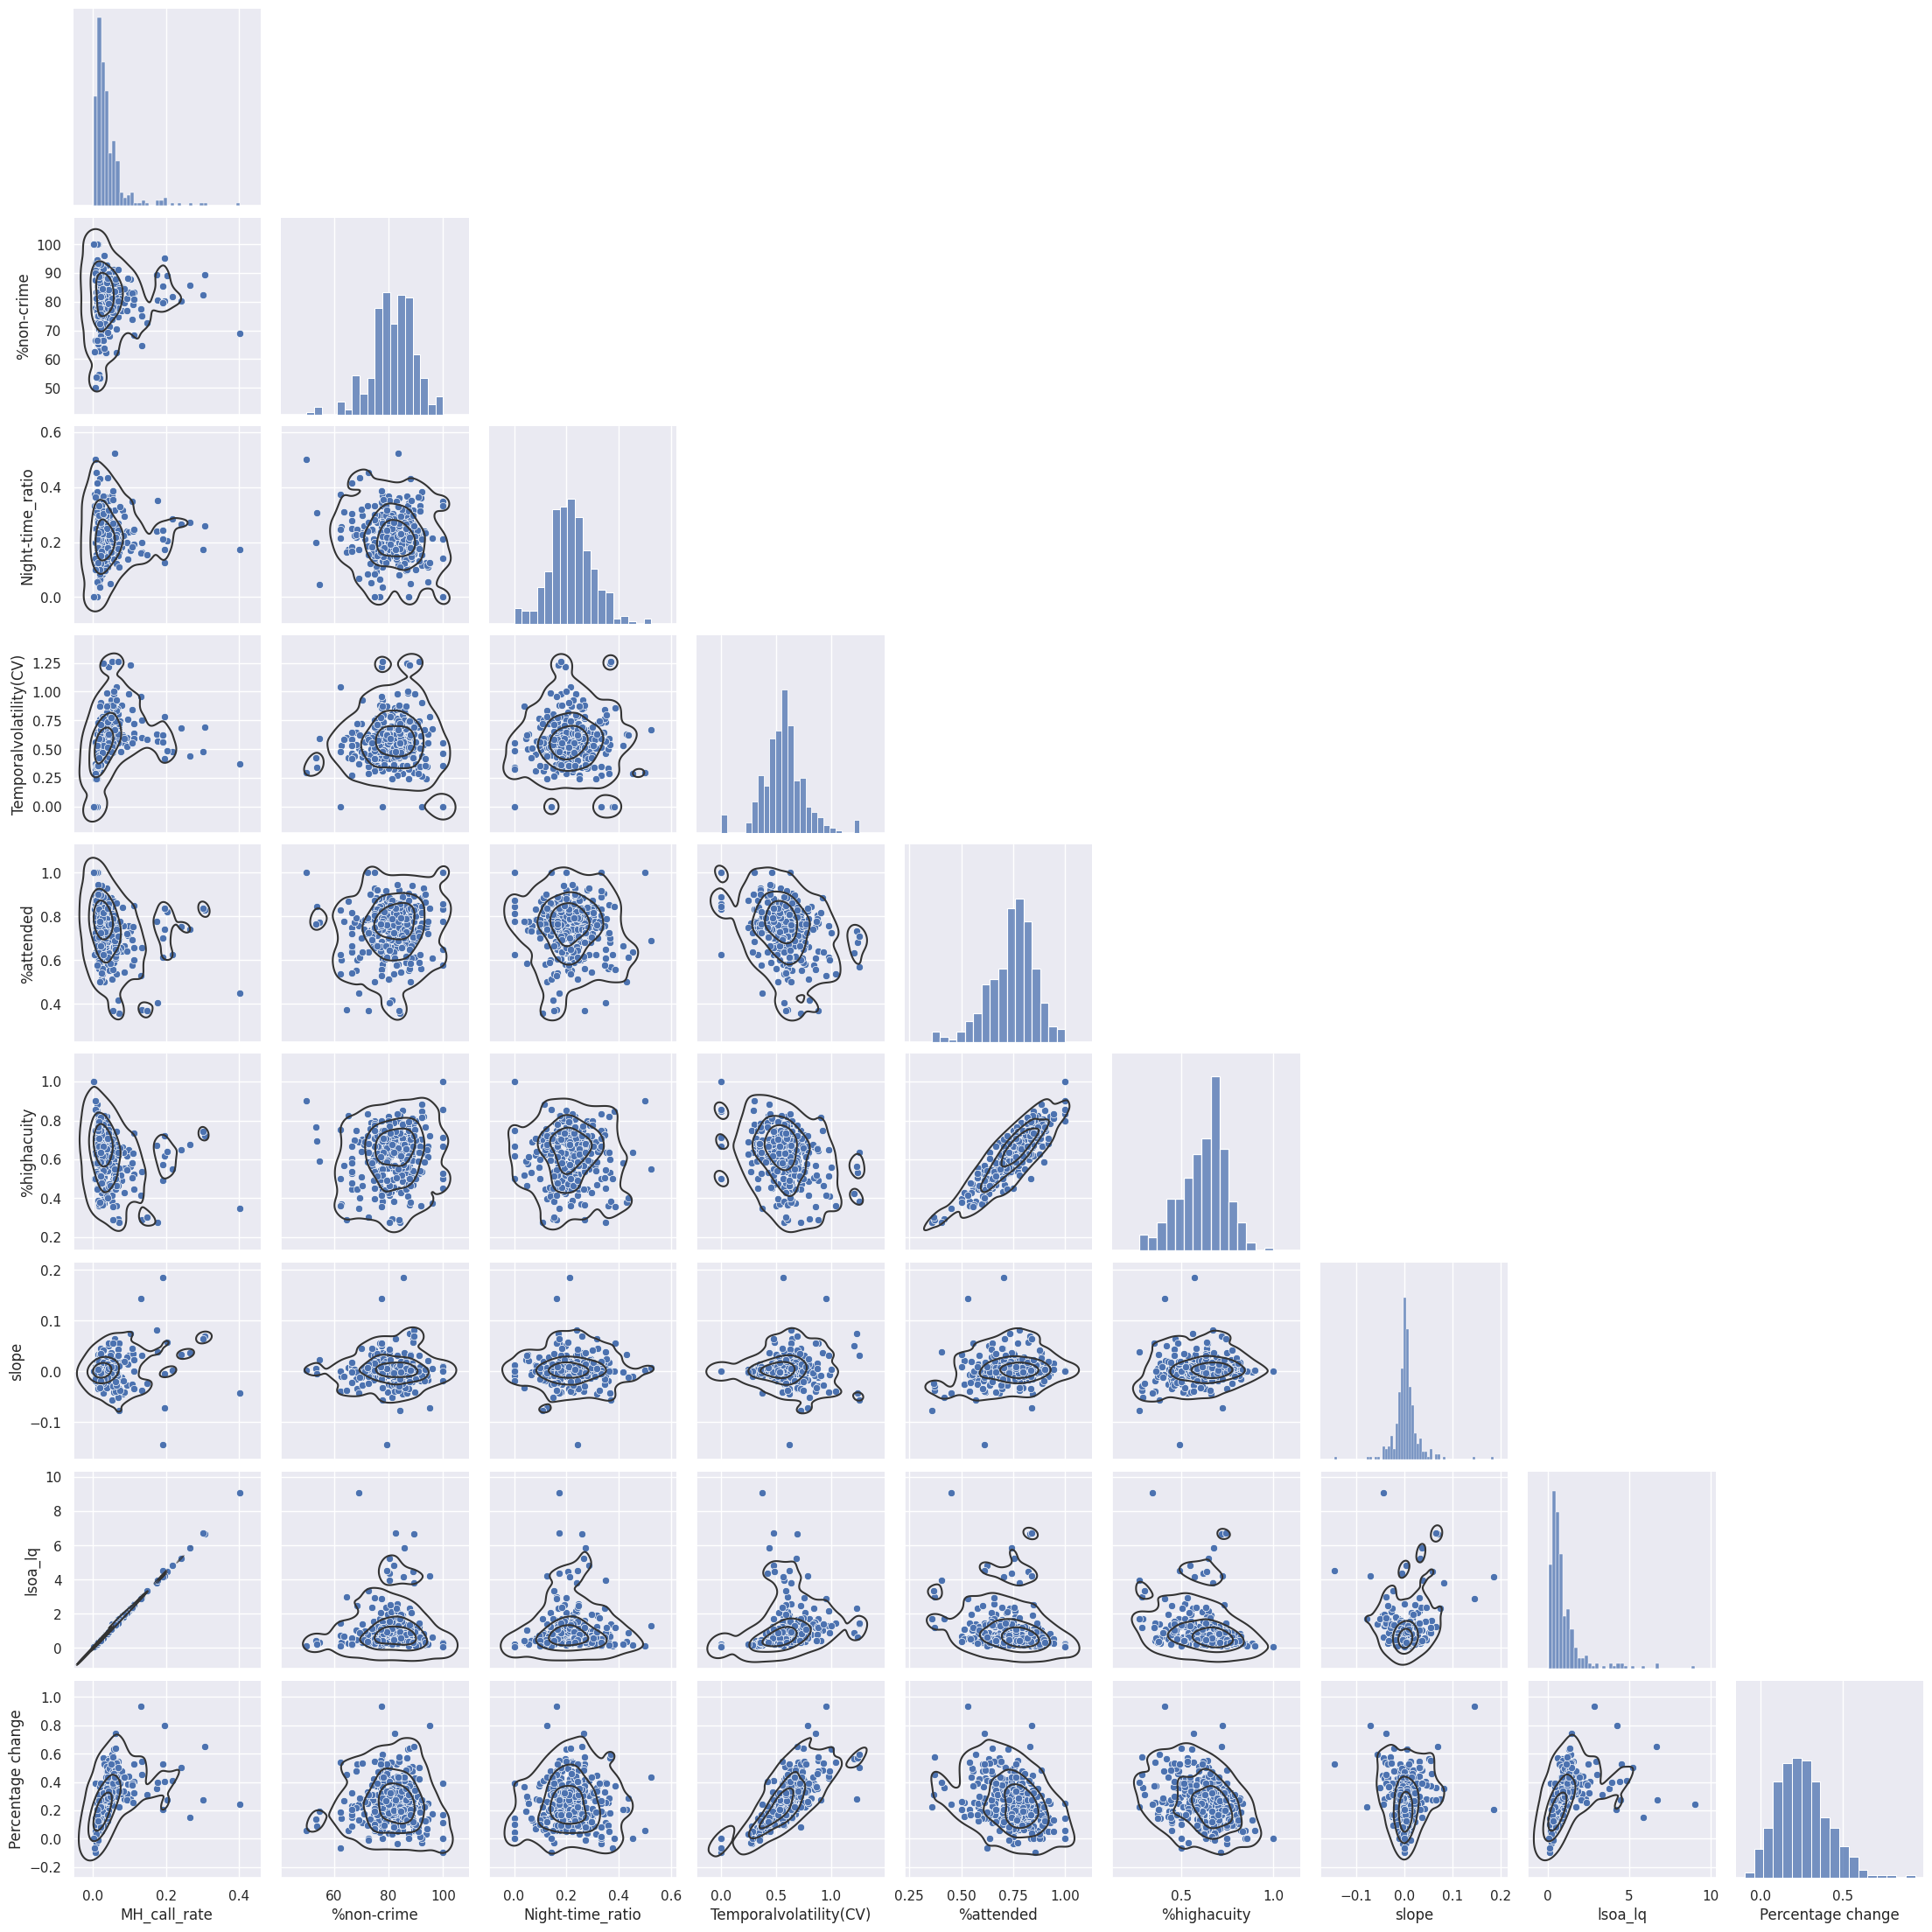

In [6]:
# Pairwise relationship of the indicators
g = sns.pairplot(df_explore, diag_kind="hist",corner=True)
g.map_lower(sns.kdeplot,levels=4,color=".2") # matplotlib dependency conflict with data-science-utils library

<Axes: >

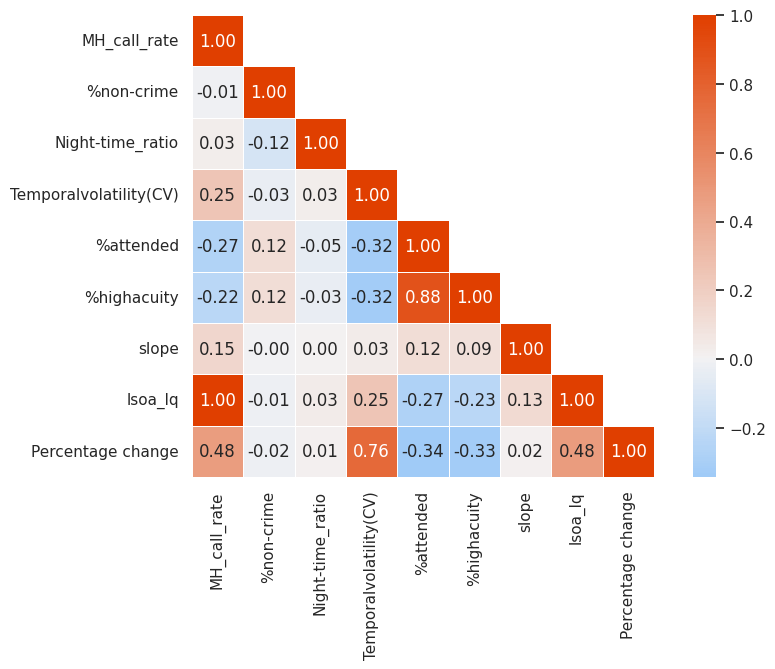

In [7]:
# Correlation heatmap
sns.set_theme(style='white')
compute_corr = df_explore.corr()
# mask = np.triu(np.ones_like(compute_corr,dtype=bool))
mask = np.triu(compute_corr,1)

fig,ax=plt.subplots(figsize=(10,6))
# fig.patch.set_facecolor('white')

cmap = sns.diverging_palette(250, 30, s=200, l=50, as_cmap=True)

sns.heatmap(compute_corr, mask=mask, cmap=cmap, annot=True,fmt=".2f", center=0,
            square=True, linewidths=.5)

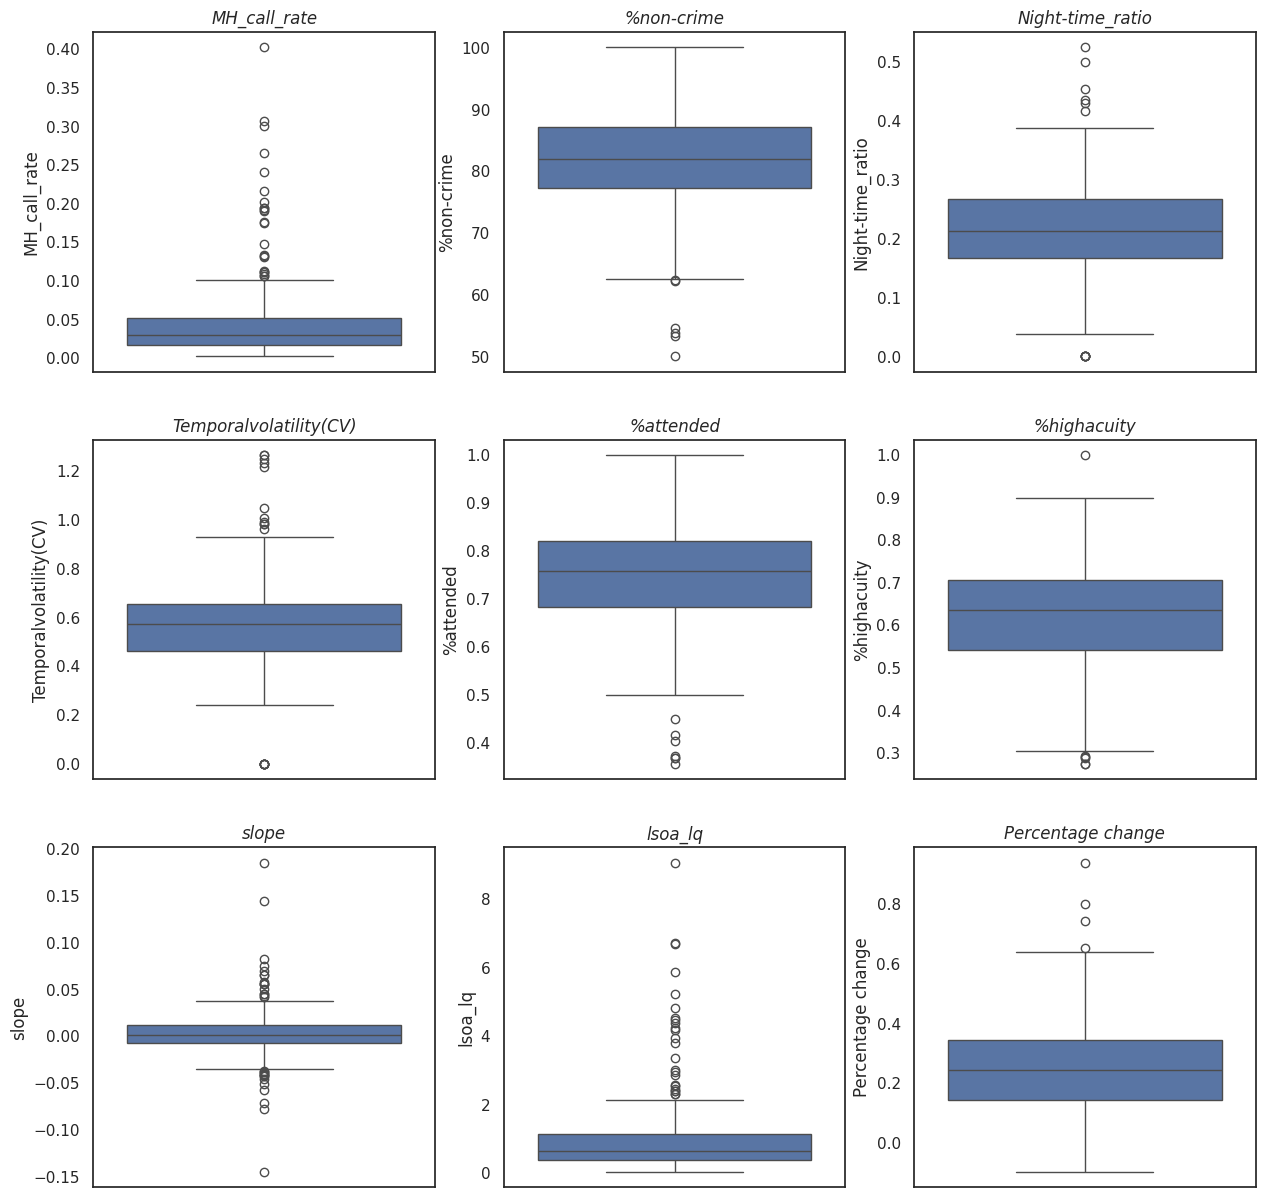

In [8]:
fig, ax = plt.subplots(nrows=3,ncols=3,figsize=(15, 15))
ax=ax.flatten()
for i,cols in enumerate(df_explore.columns):
    sns.boxplot(data=df_explore[cols],ax=ax[i])
    ax[i].set_title(cols, fontstyle='italic')

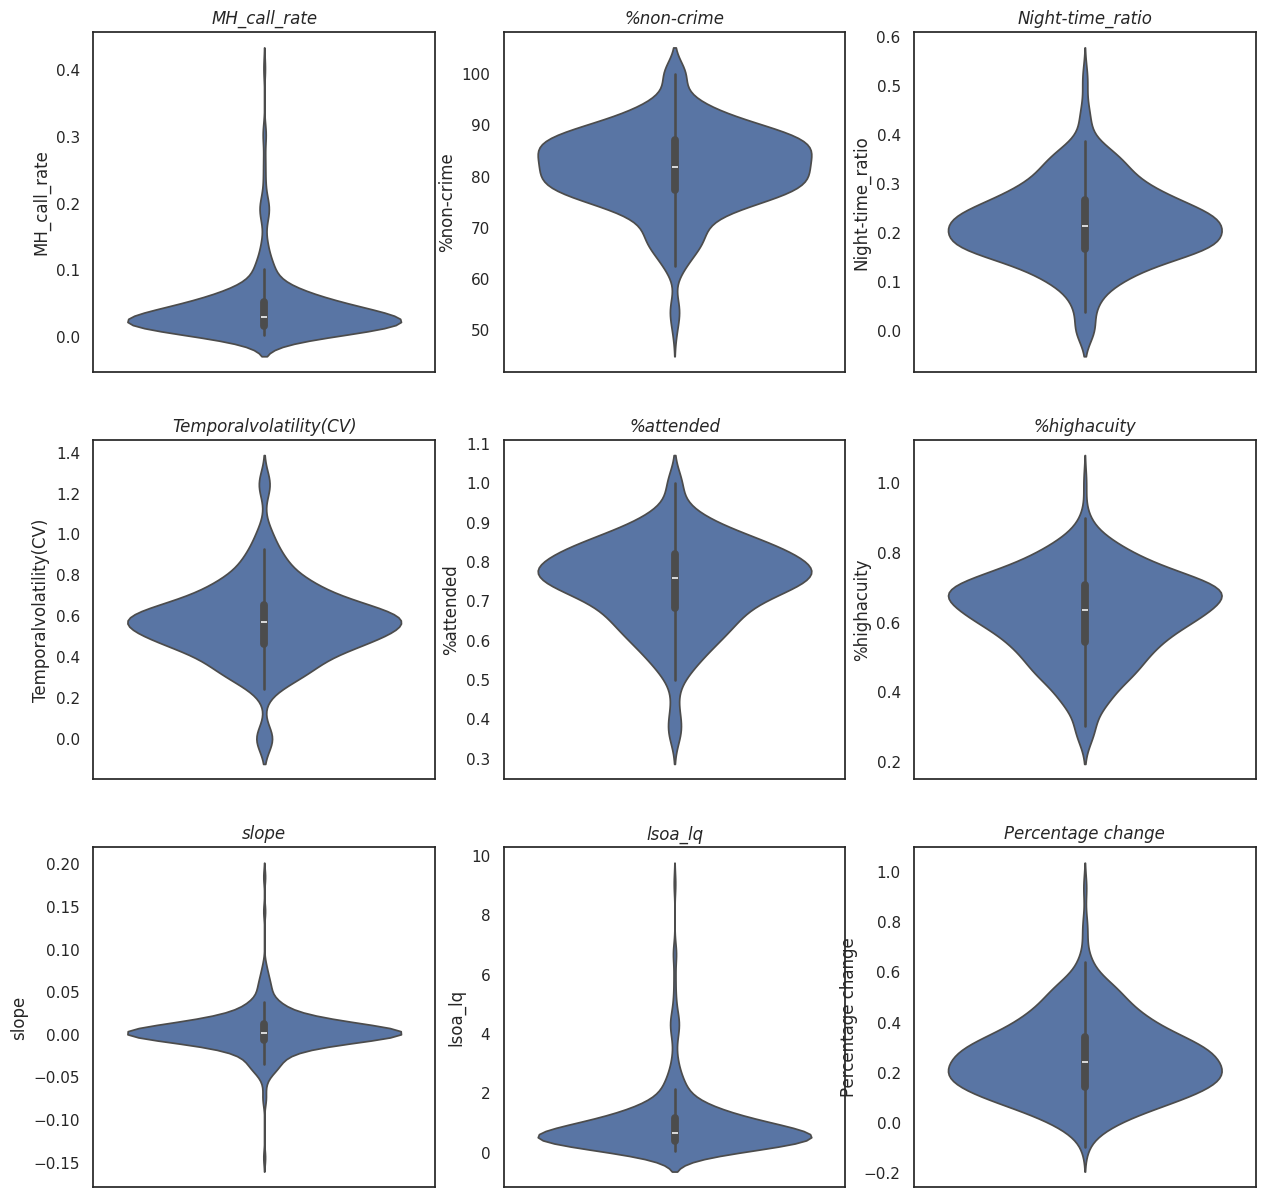

In [9]:
fig, ax = plt.subplots(nrows=3,ncols=3,figsize=(15, 15))
ax=ax.flatten()
for i,cols in enumerate(df_explore.columns):
    sns.violinplot(data=df_explore[cols],ax=ax[i])
    ax[i].set_title(cols, fontstyle='italic')

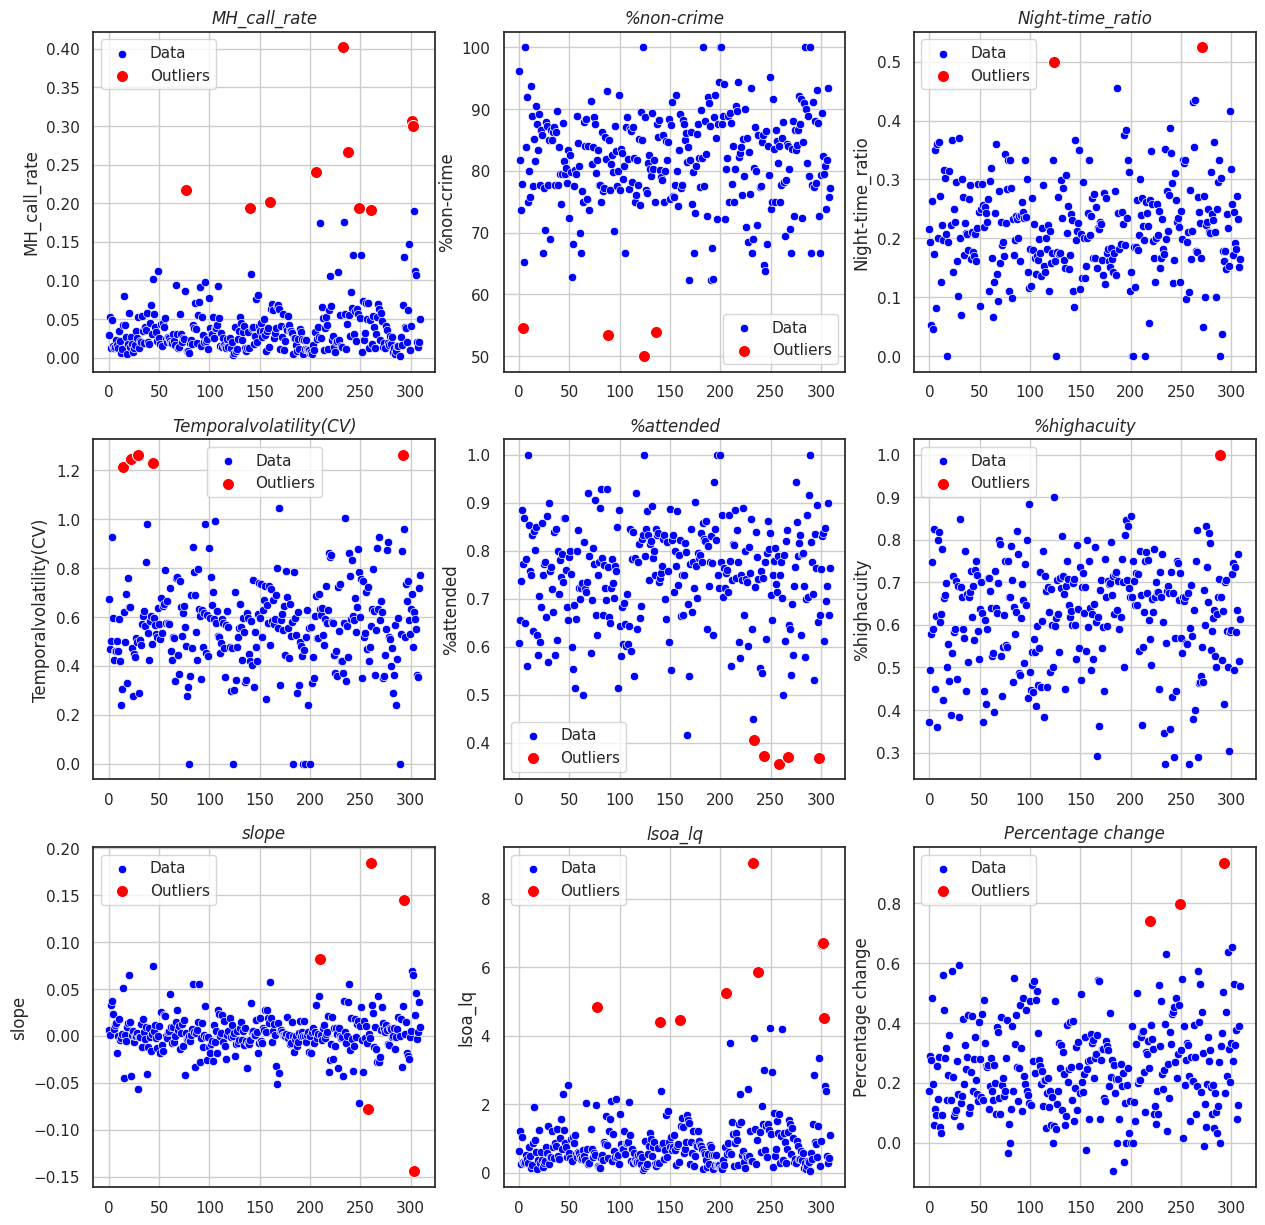

In [10]:
# Calculate z-scores for the dataset
z_scores = zscore(df_explore)

# Identify outliers based on threshold
fig, ax = plt.subplots(nrows=3,ncols=3,figsize=(15, 15))
ax=ax.flatten()
for i,cols in enumerate(df_explore.columns):
    outliers_mask = np.abs(z_scores[cols]) > 3 #outlier_threshold = 3.0
    outlier_indices = df_explore[outliers_mask].iloc[:, i]
    sns.scatterplot(x=np.arange(len(df_explore)), y=df_explore[cols], ax=ax[i], color='blue', label='Data')
    sns.scatterplot(x=np.arange(len(df_explore))[outlier_indices.index], y=df_explore[cols][outlier_indices.index], ax=ax[i], color='red', s=75, label='Outliers')
    ax[i].grid()
    ax[i].set_title(cols, fontstyle='italic')

In [11]:
def identify_zscore_outliers(df):
    z_outliers = {}
    for column in df.columns:
        z_scores = zscore(df[column])
        outliers_mask = np.abs(z_scores) > 3
        z_outliers[column] = df[outliers_mask].index.tolist()
    return z_outliers

outliers_zscore = identify_zscore_outliers(df_explore)
print("Outliers detected in each column (index, value):")
for column, values in outliers_zscore.items():
    print(f"{column.upper()}: no. of elements-{len(values)}, {values}")

Outliers detected in each column (index, value):
MH_CALL_RATE: no. of elements-10, [77, 140, 160, 206, 233, 238, 249, 261, 301, 302]
%NON-CRIME: no. of elements-4, [4, 88, 124, 136]
NIGHT-TIME_RATIO: no. of elements-2, [124, 271]
TEMPORALVOLATILITY(CV): no. of elements-5, [14, 22, 29, 44, 292]
%ATTENDED: no. of elements-5, [234, 243, 258, 267, 298]
%HIGHACUITY: no. of elements-1, [289]
SLOPE: no. of elements-5, [210, 258, 261, 293, 303]
LSOA_LQ: no. of elements-9, [77, 140, 160, 206, 233, 238, 301, 302, 303]
PERCENTAGE CHANGE: no. of elements-3, [219, 249, 293]


In [12]:
from collections import Counter,defaultdict

# Find indices that are outliers in all columns
idx = [val for key,val in outliers_zscore.items()]
index_counts = Counter(sum(idx,[]))

# Get lists of indices based on frequency thresholds
more_than_1 = [i for i, c in index_counts.items() if c > 1]
# Get lsoa codes based on list of indices
lsoa_more_than_1 = df_indicators[df_indicators.index.isin(more_than_1)]['LSOA11CD'].values

# get the outlier specific columns for each lsoa
idx_to_cols = defaultdict(list)
for key,val in outliers_zscore.items():
    for j,idx in enumerate(val):
        if idx in more_than_1:        
            idx_to_cols[idx].append(key.upper())

# Convert the dict to dataframe
index_map_lsoa = {i:j for i,j in zip(more_than_1,lsoa_more_than_1)}
lsoa_outlier_cols = {index_map_lsoa.get(k, k): v for k, v in idx_to_cols.items()}
outlier_list = pd.DataFrame.from_dict(lsoa_outlier_cols,orient='index')
outlier_list

,0,1
E01010645,MH_CALL_RATE,LSOA_LQ
E01010694,MH_CALL_RATE,LSOA_LQ
E01010710,MH_CALL_RATE,LSOA_LQ
E01010730,MH_CALL_RATE,LSOA_LQ
E01010777,MH_CALL_RATE,LSOA_LQ
E01010805,MH_CALL_RATE,LSOA_LQ
E01010810,MH_CALL_RATE,PERCENTAGE CHANGE
E01010821,MH_CALL_RATE,SLOPE
E01010831,MH_CALL_RATE,LSOA_LQ
E01010834,MH_CALL_RATE,LSOA_LQ


In [13]:
# filtering data based on z-score
df_explore_filter = df_explore[~df_explore.index.isin(list(index_counts.keys()))]

In [14]:
def identify_outliers(df):
    outliers = {}
    for column in df.columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers[column] = df[(df[column] < lower_bound) | (df[column] > upper_bound)][[column]].index.tolist()
    return outliers


outliers = identify_outliers(df_explore)
print("Outliers detected in each column (index, value):")
for column, values in outliers.items():
    print(f"{column.upper()}: no. of elements-{len(values)}, {values}")

Outliers detected in each column (index, value):
MH_CALL_RATE: no. of elements-23, [49, 77, 140, 141, 160, 206, 210, 220, 228, 233, 234, 238, 243, 249, 251, 261, 293, 298, 301, 302, 303, 304, 305]
%NON-CRIME: no. of elements-6, [4, 88, 124, 136, 169, 191]
NIGHT-TIME_RATIO: no. of elements-12, [18, 124, 126, 187, 201, 202, 214, 262, 264, 271, 289, 299]
TEMPORALVOLATILITY(CV): no. of elements-18, [14, 22, 29, 38, 44, 80, 96, 106, 123, 169, 183, 193, 195, 200, 235, 289, 292, 293]
%ATTENDED: no. of elements-7, [167, 233, 234, 243, 258, 267, 298]
%HIGHACUITY: no. of elements-6, [167, 234, 243, 258, 267, 289]
SLOPE: no. of elements-30, [14, 15, 20, 22, 29, 38, 44, 61, 76, 84, 90, 160, 167, 169, 209, 210, 219, 233, 239, 243, 249, 253, 258, 261, 268, 293, 301, 302, 303, 305]
LSOA_LQ: no. of elements-24, [44, 49, 77, 140, 141, 160, 206, 210, 220, 228, 233, 234, 238, 243, 249, 251, 261, 293, 298, 301, 302, 303, 304, 305]
PERCENTAGE CHANGE: no. of elements-4, [219, 249, 293, 301]


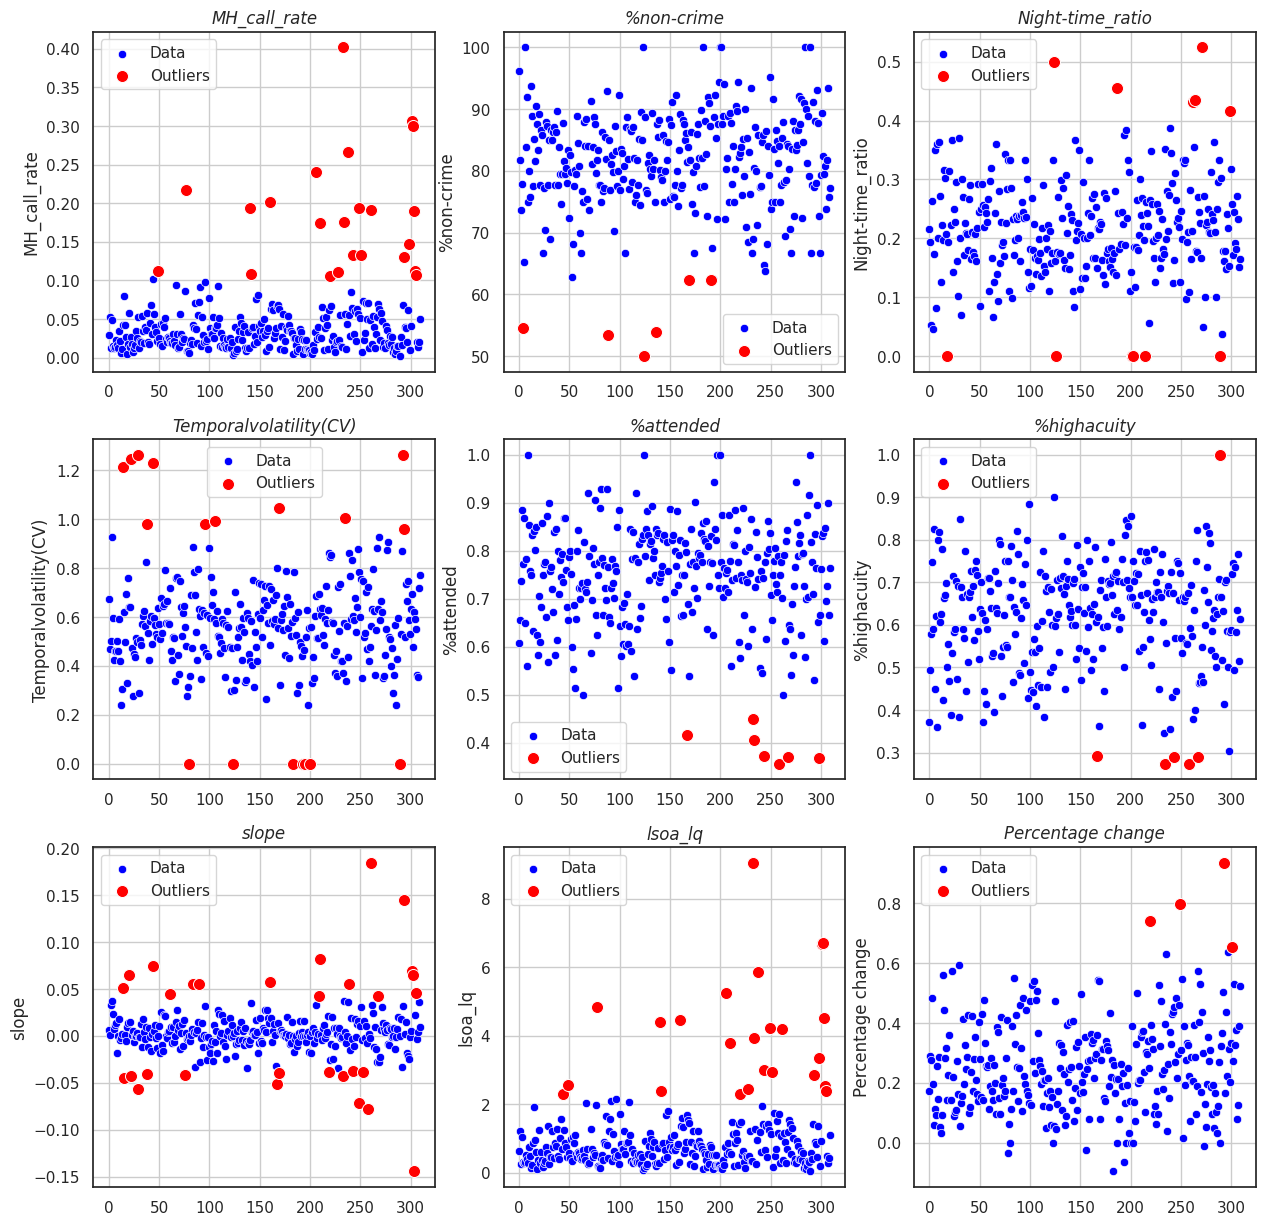

In [15]:
# Identify outliers based on IQR
fig, ax = plt.subplots(nrows=3,ncols=3,figsize=(15, 15))
ax=ax.flatten()
for i,cols in enumerate(df_explore.columns):
    outlier_indices = outliers[cols]
    sns.scatterplot(x=np.arange(len(df_explore)), y=df_explore[cols], ax=ax[i], color='blue', label='Data')
    sns.scatterplot(x=np.arange(len(df_explore))[outlier_indices], y=df_explore[cols][outlier_indices], ax=ax[i], color='red', s=75, label='Outliers')
    ax[i].grid()
    ax[i].set_title(cols, fontstyle='italic')

In [16]:
from collections import Counter,defaultdict

# Find indices that are outliers in all columns
idx = [val for key,val in outliers.items()]
index_counts = Counter(sum(idx,[]))

# Get lists of indices based on frequency thresholds
more_than_1 = [i for i, c in index_counts.items() if c > 1]
more_than_2 = [i for i, c in index_counts.items() if c > 2]
more_than_3 = [i for i, c in index_counts.items() if c > 3]
more_than_4 = [i for i, c in index_counts.items() if c > 4]

lsoa_more_than_1 = df_indicators[df_indicators.index.isin(more_than_1)]['LSOA11CD'].values
lsoa_more_than_2 = df_indicators[df_indicators.index.isin(more_than_2)]['LSOA11CD'].values
lsoa_more_than_3 = df_indicators[df_indicators.index.isin(more_than_3)]['LSOA11CD'].values
lsoa_more_than_4 = df_indicators[df_indicators.index.isin(more_than_4)]['LSOA11CD'].values

print(f'more_than_1_column: {lsoa_more_than_1},\nmore_than_2_columns: {lsoa_more_than_2},\nmore_than_3_columns: {lsoa_more_than_3},\nmore_than_4_columns: {lsoa_more_than_4}')

more_than_1_column: ['E01010582' 'E01010590' 'E01010597' 'E01010606' 'E01010612' 'E01010617'
 'E01010645' 'E01010694' 'E01010710' 'E01010711' 'E01010730' 'E01010737'
 'E01010739' 'E01010777' 'E01010782' 'E01010791' 'E01010792' 'E01010800'
 'E01010805' 'E01010806' 'E01010810' 'E01010815' 'E01010821' 'E01010824'
 'E01010831' 'E01010834' 'E01010840' 'E01010863' 'E01010867' 'E01010872'
 'E01033689' 'E01033690' 'E01033691' 'E01033692' 'E01033693'],
more_than_2_columns: ['E01010612' 'E01010730' 'E01010737' 'E01010739' 'E01010782' 'E01010805'
 'E01010806' 'E01010815' 'E01010821' 'E01010831' 'E01010834' 'E01010863'
 'E01010867' 'E01010872' 'E01033689' 'E01033690' 'E01033691' 'E01033693'],
more_than_3_columns: ['E01010805' 'E01010806' 'E01010815' 'E01010821' 'E01010867' 'E01033689'],
more_than_4_columns: ['E01010815' 'E01010867']


In [17]:
idx_to_cols = defaultdict(list)

for key,val in outliers.items():
    for j,idx in enumerate(val):
        if idx in more_than_1:        
            idx_to_cols[idx].append(key.upper())

In [18]:
index_map_lsoa = {i:j for i,j in zip(more_than_1,lsoa_more_than_1)}
lsoa_outlier_cols = {index_map_lsoa.get(k, k): v for k, v in idx_to_cols.items()}
outlier_list = pd.DataFrame.from_dict(lsoa_outlier_cols,orient='index')
outlier_list

,0,1,2,3,4
E01010582,MH_CALL_RATE,LSOA_LQ,None,None,None
E01010590,MH_CALL_RATE,LSOA_LQ,None,None,None
E01010597,MH_CALL_RATE,LSOA_LQ,None,None,None
E01010606,MH_CALL_RATE,LSOA_LQ,None,None,None
E01010612,MH_CALL_RATE,SLOPE,LSOA_LQ,None,None
E01010617,MH_CALL_RATE,LSOA_LQ,None,None,None
E01010645,MH_CALL_RATE,SLOPE,LSOA_LQ,None,None
E01010694,MH_CALL_RATE,LSOA_LQ,None,None,None
E01010710,MH_CALL_RATE,LSOA_LQ,None,None,None
E01010711,MH_CALL_RATE,%ATTENDED,SLOPE,LSOA_LQ,None


In [19]:
import matplotlib.cm as cm

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score,silhouette_samples

from sklearn.preprocessing import LabelEncoder

from scipy.spatial.distance import cdist

# 3. Data Analysis: Clustering

## 3.1 K-means

In [20]:
df_explore_filter.columns

Index(['MH_call_rate', '%non-crime', 'Night-time_ratio',
       'Temporalvolatility(CV)', '%attended', '%highacuity', 'slope',
       'lsoa_lq', 'Percentage change'],
      dtype='object')

In [21]:
# X = df_explore[['MH_call_rate','%non-crime', 'Night-time_ratio','Temporalvolatility(CV)', '%attended', '%highacuity', 'slope','lsoa_lq', 'Percentage change']]
X = df_explore[['MH_call_rate','%non-crime', 'Night-time_ratio', '%attended','%highacuity', 'slope']] #Dropped 'Temporalvolatility(CV)', 'lsoa_lq', 'Percentage change'
X.head(2)

,MH_call_rate,%non-crime,Night-time_ratio,%attended,%highacuity,slope
0,0.029668,96.078431,0.215686,0.607843,0.372549,0.006048
1,0.052961,81.720430,0.193548,0.655914,0.494624,0.001164


In [22]:
distortions = []
inertias = []
map_distortion = {}
map_inertia = {}

for k in range(1, 10):
    kmeanModel = KMeans(n_clusters=k, init= 'k-means++',random_state=42).fit(X)    
    distortions.append(sum(np.min(cdist(X, kmeanModel.cluster_centers_, 'euclidean'), axis=1)**2) / X.shape[0])    
    inertias.append(kmeanModel.inertia_)
    
    map_distortion[k] = distortions[-1]
    map_inertia[k] = inertias[-1]

Distortion values:
1 : 65.63788662806031
2 : 26.46624980386703
3 : 13.819986120612585
4 : 11.135197657027648
5 : 6.823734335503669
6 : 4.002336692764855
7 : 2.989330852180252
8 : 2.2273677144099686
9 : 1.5707601791711734


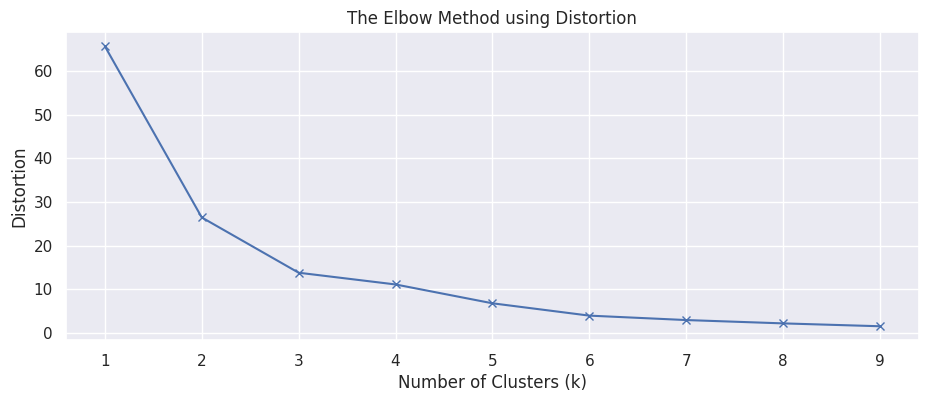

In [23]:
sns.set_theme()
print("Distortion values:")
for key, val in map_distortion.items():
    print(f'{key} : {val}')

plt.plot(range(1, 10), distortions, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Distortion')
plt.title('The Elbow Method using Distortion')
plt.show()

Inertia values:
1 : 20347.744854698693
2 : 8204.537439198777
3 : 4284.195697389901
4 : 3451.911273678571
5 : 2115.3576440061365
6 : 1240.724374757105
7 : 926.6925641758781
8 : 690.48399146709
9 : 486.9356555430639


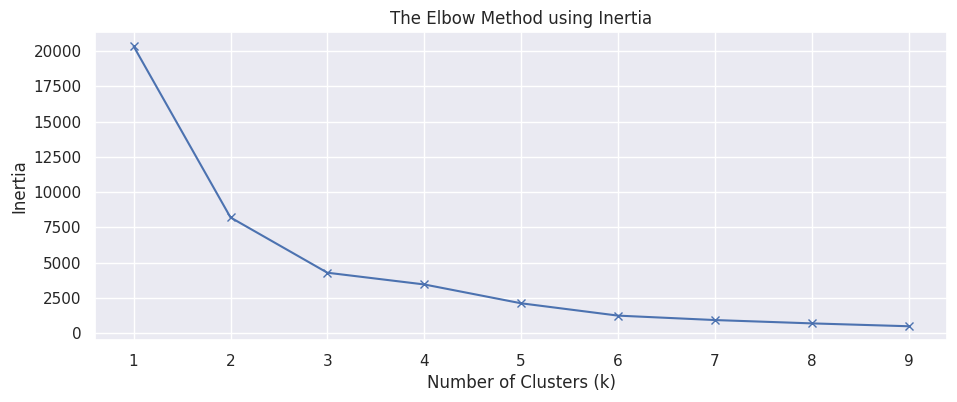

In [24]:
print("Inertia values:")
for key, val in map_inertia.items():
    print(f'{key} : {val}')

plt.plot(range(1, 10), inertias, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method using Inertia')
plt.show()

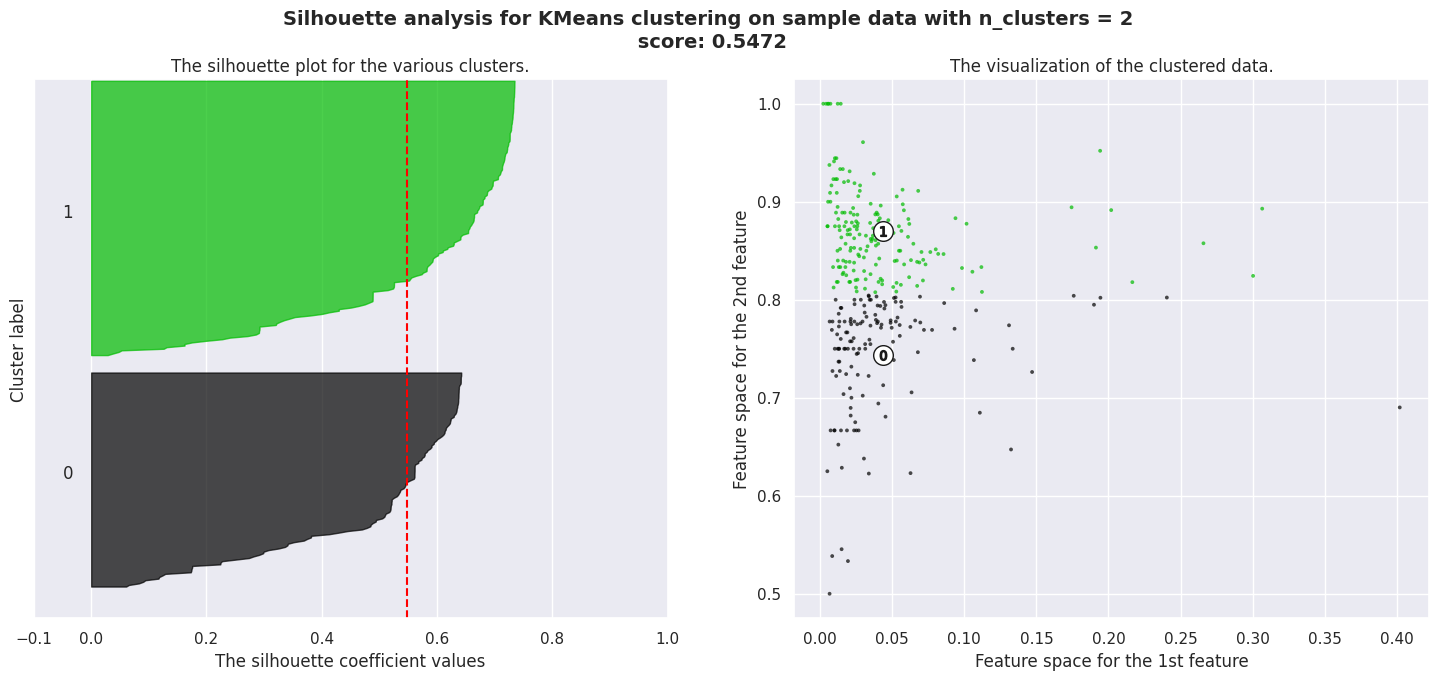

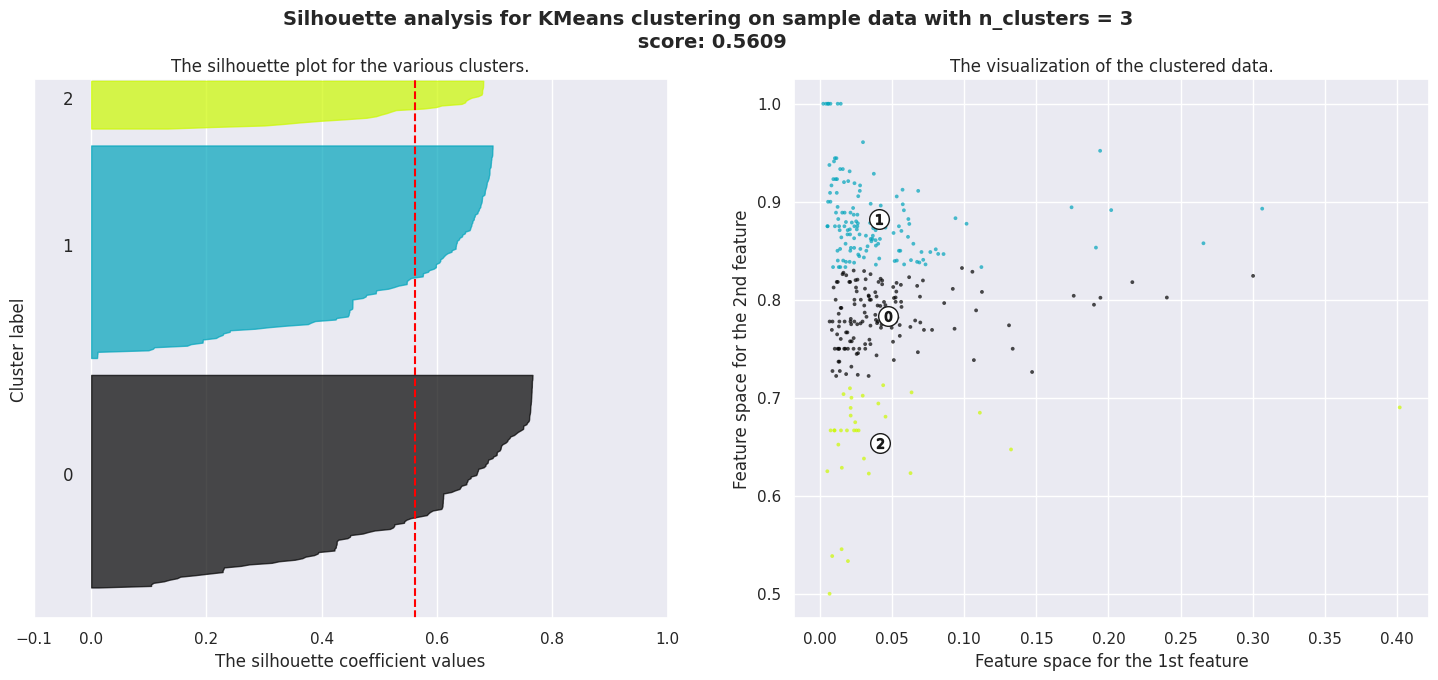

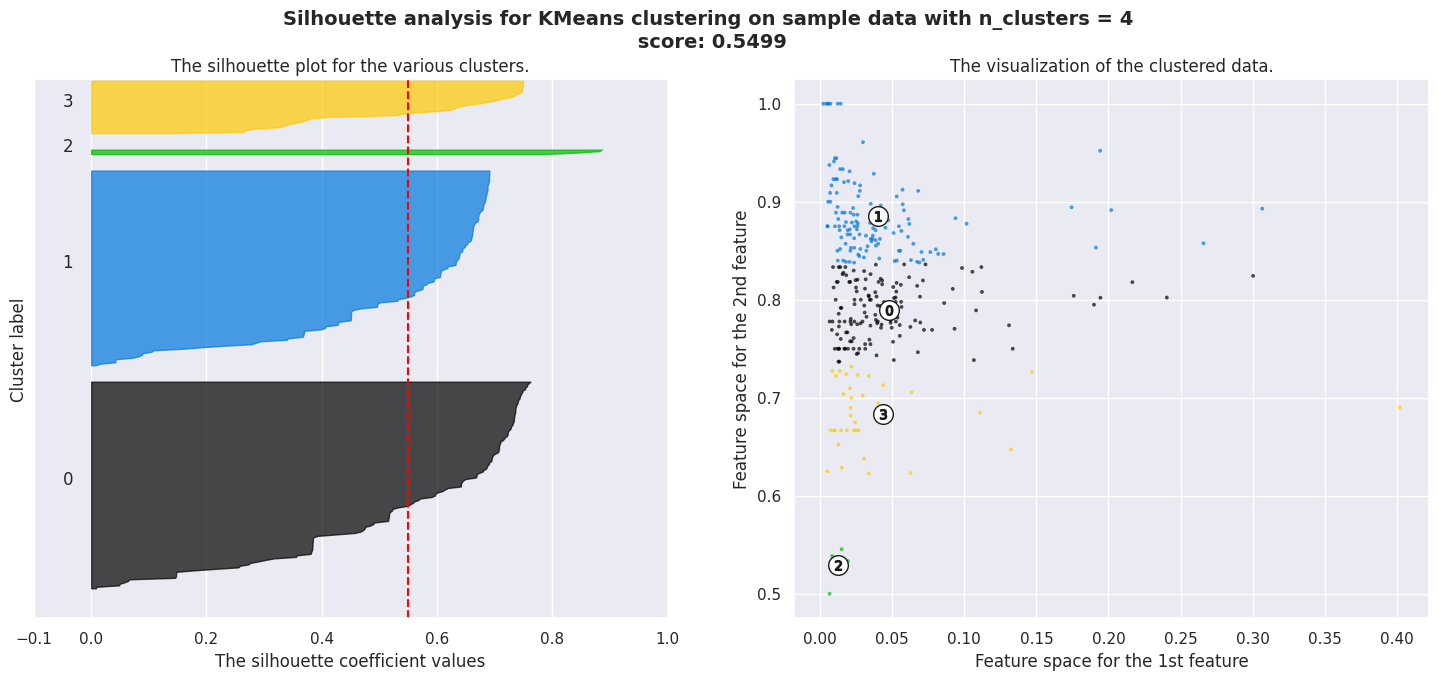

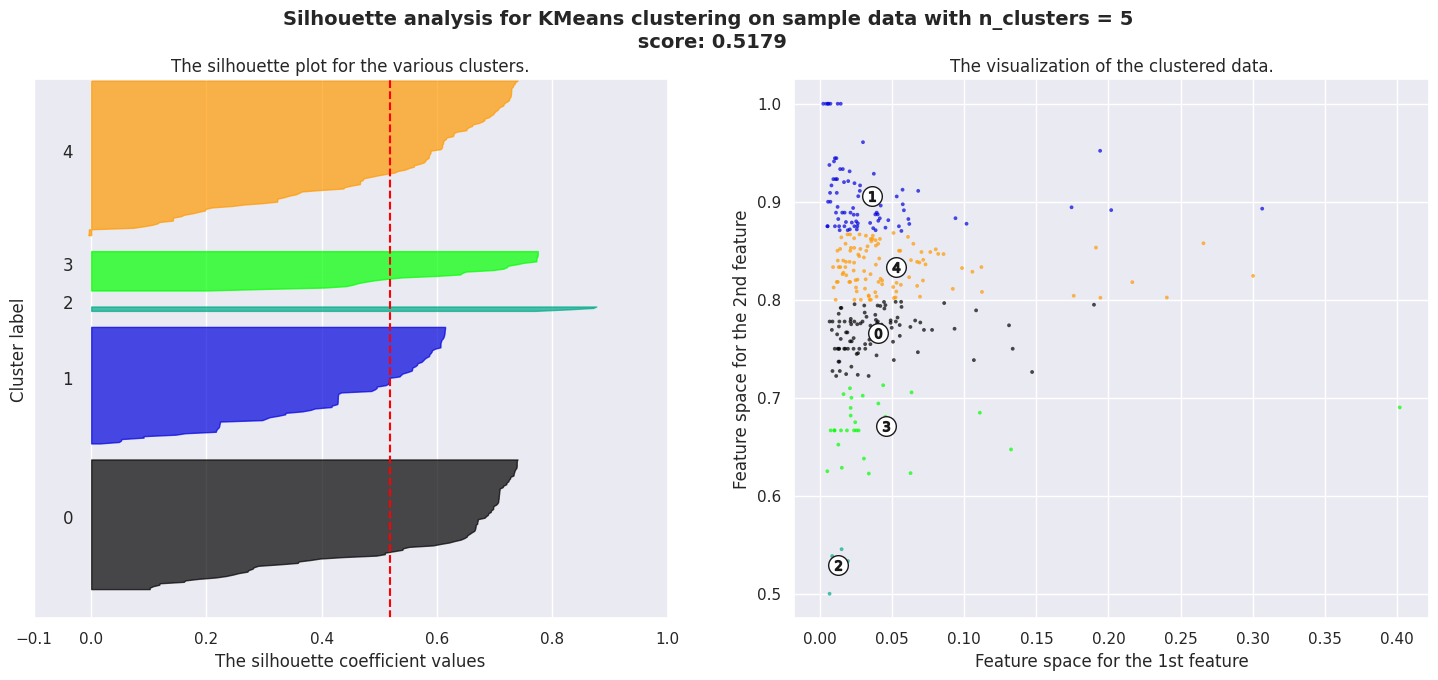

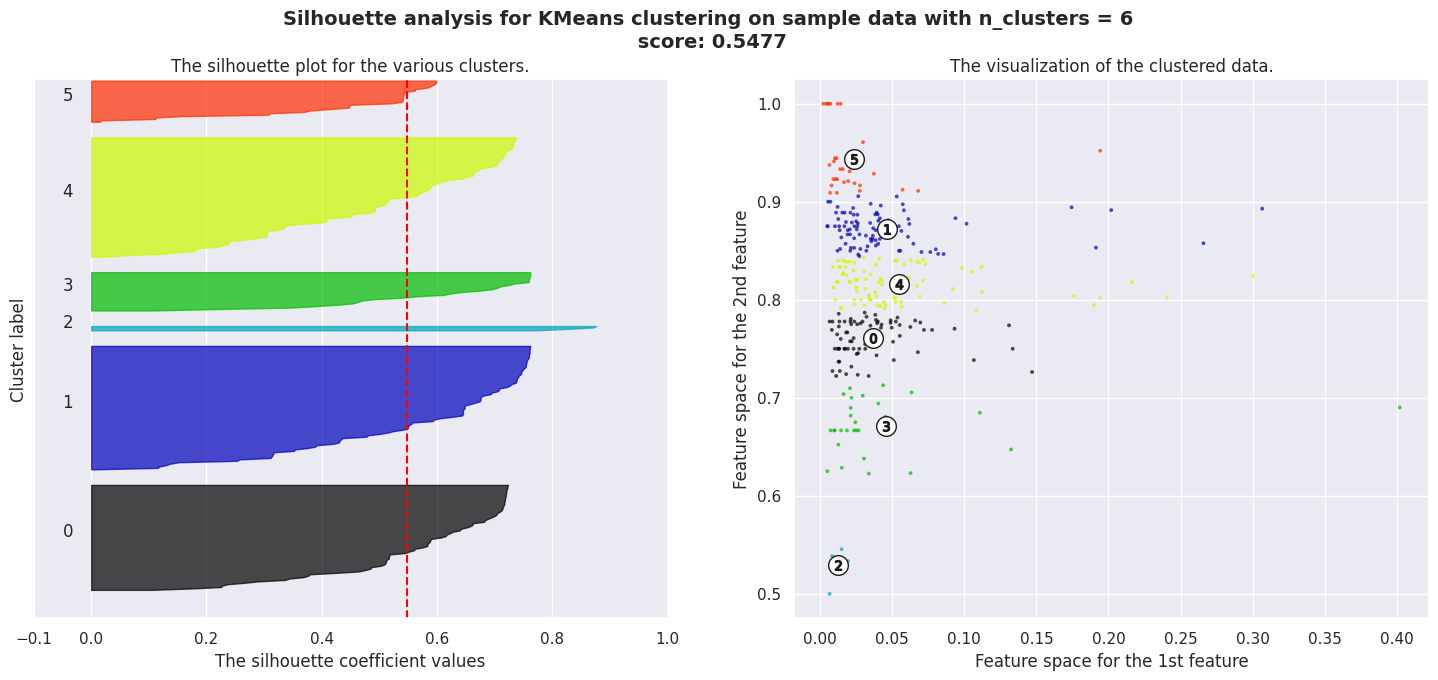

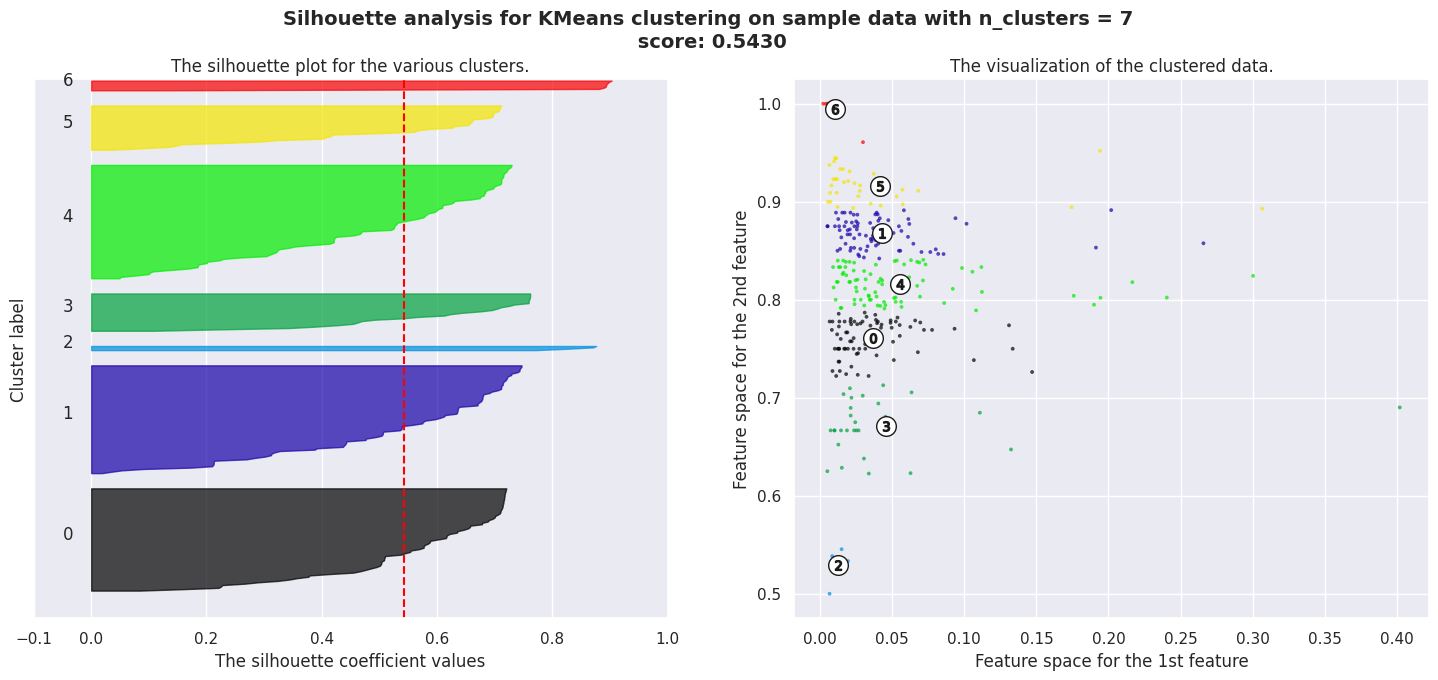

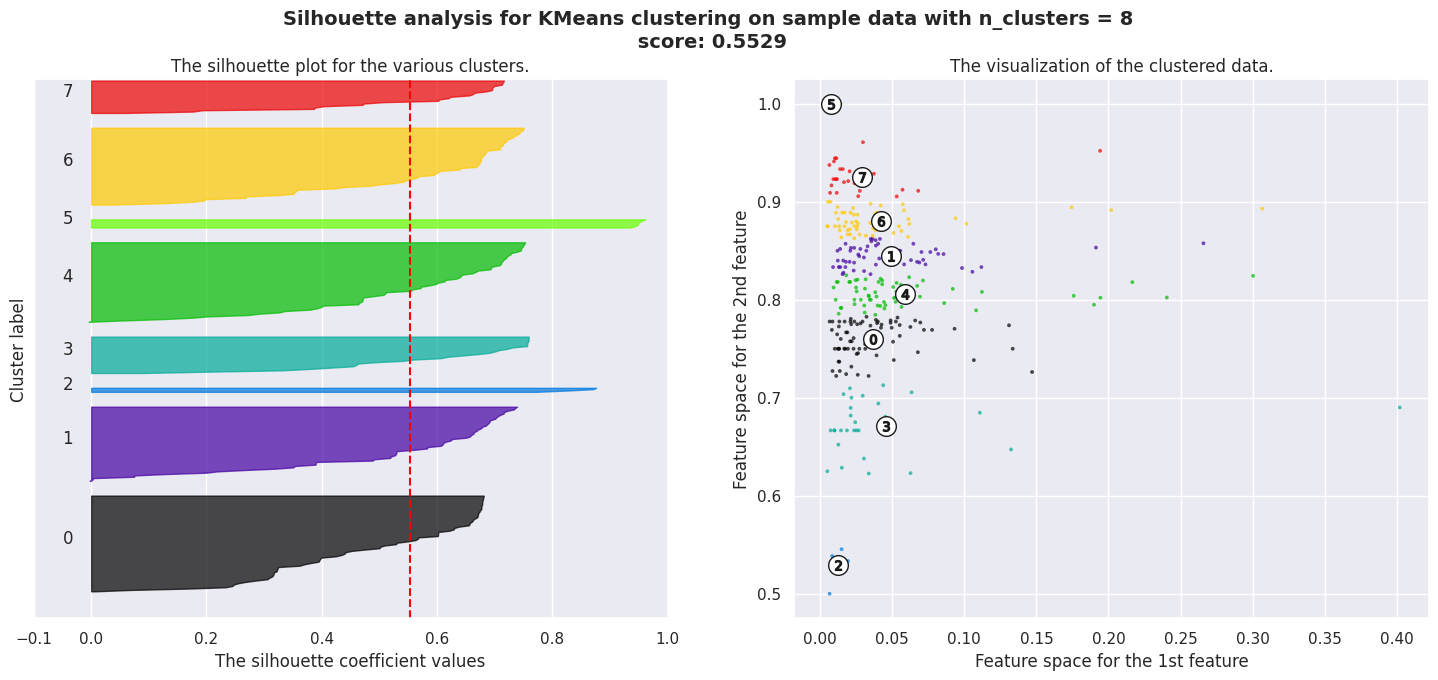

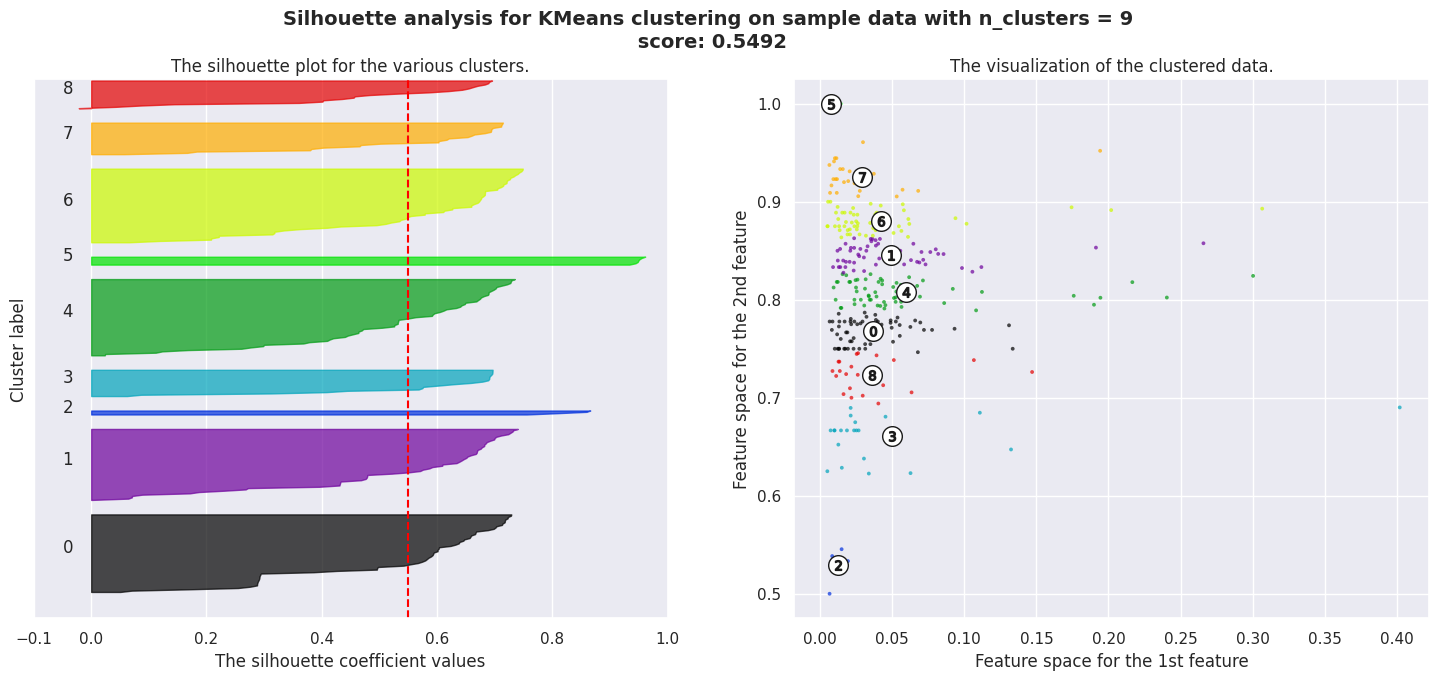

In [25]:
# Adapted from https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html

silhouette_scores = []

for n_clusters in range(2, 10):
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    cluster = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = cluster.fit_predict(X)

    silhouette_avg = silhouette_score(X, cluster_labels)
    silhouette_scores.append(silhouette_avg)

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 20
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        X.iloc[:, 0], X.iloc[:, 1]/100, marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # Labeling the clusters
    centers = cluster.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0],
        centers[:, 1]/100,
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1]/100, marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d\n score: %.4f"
        % (n_clusters,silhouette_avg),
        fontsize=14,
        fontweight="bold",
    )

plt.show()

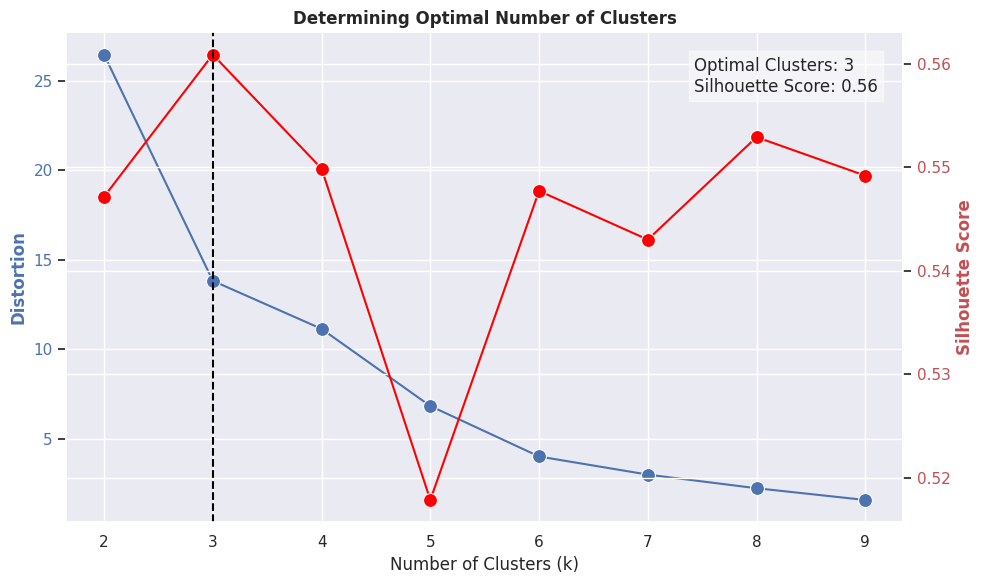

In [26]:
cluster_range = np.arange(2,10)
optimal_clusters = cluster_range[silhouette_scores.index(max(silhouette_scores))]
optimal_score = max(silhouette_scores)

fig, ax1 = plt.subplots(figsize=(10,6))

sns.lineplot(x=cluster_range, y=distortions[1:],ax=ax1, marker='o',markersize=10)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Distortion', color='b',fontweight='bold')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
sns.lineplot(x=cluster_range, y=silhouette_scores,ax=ax2, color='red',marker='o',markersize=10)
ax2.set_ylabel('Silhouette Score', color='r',fontweight='bold')
ax2.tick_params(axis='y', labelcolor='r')

plt.axvline(x=optimal_clusters, color='black', linestyle='--')
plt.text(0.75, 0.95, f'Optimal Clusters: {optimal_clusters}\nSilhouette Score: {optimal_score:.2f}', 
            horizontalalignment='left', verticalalignment='top', transform=plt.gca().transAxes, 
            bbox=dict(facecolor='white', alpha=0.5))

plt.title('Determining Optimal Number of Clusters',fontweight='bold')

plt.tight_layout()
plt.show()

In [27]:
model = KMeans(n_clusters=3, init= 'k-means++',n_init=1) 
lsoa_kmeans = model.fit(X)

X['cluster_labels'] = lsoa_kmeans.labels_

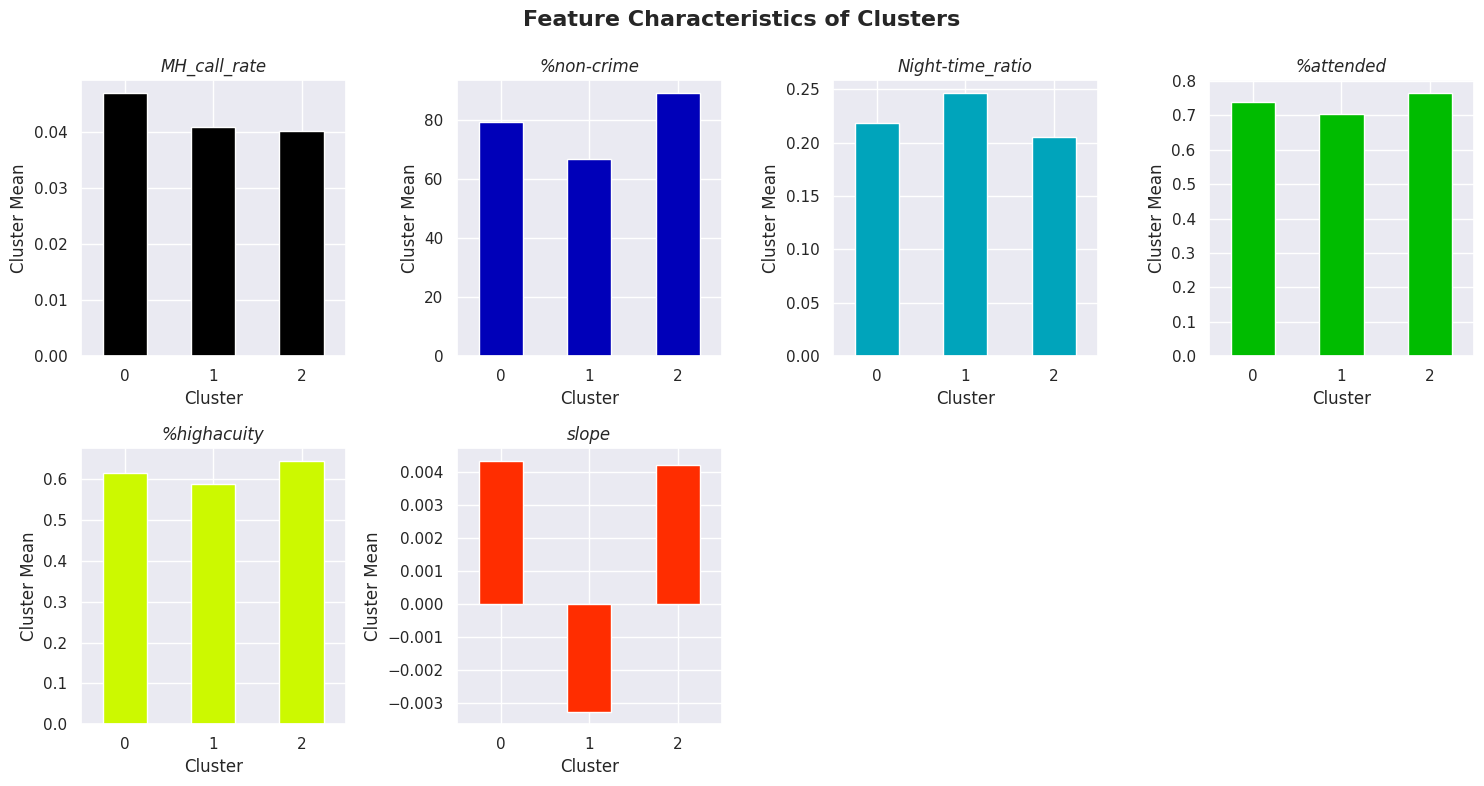

In [28]:
# Calculate the average value of each feature for each cluster
cluster_means = X.groupby('cluster_labels').mean()
num_features = len(cluster_means.columns)

fig, axes = plt.subplots(nrows=int(np.ceil(num_features / 4)), ncols=4, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(cluster_means.columns):
    cluster_means[feature].plot(kind='bar', ax=axes[i], title=feature,color=cm.nipy_spectral(i/num_features))
    axes[i].set_ylabel('Cluster Mean')
    axes[i].tick_params(axis='x', labelrotation=0)
    axes[i].set_xlabel('Cluster')
    axes[i].set_title(feature, fontstyle='italic')
    
for ax in axes.flat[cluster_means.columns.size:]:
     ax.set_axis_off()

# Set the title
fig.suptitle('Feature Characteristics of Clusters', fontsize=16,fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

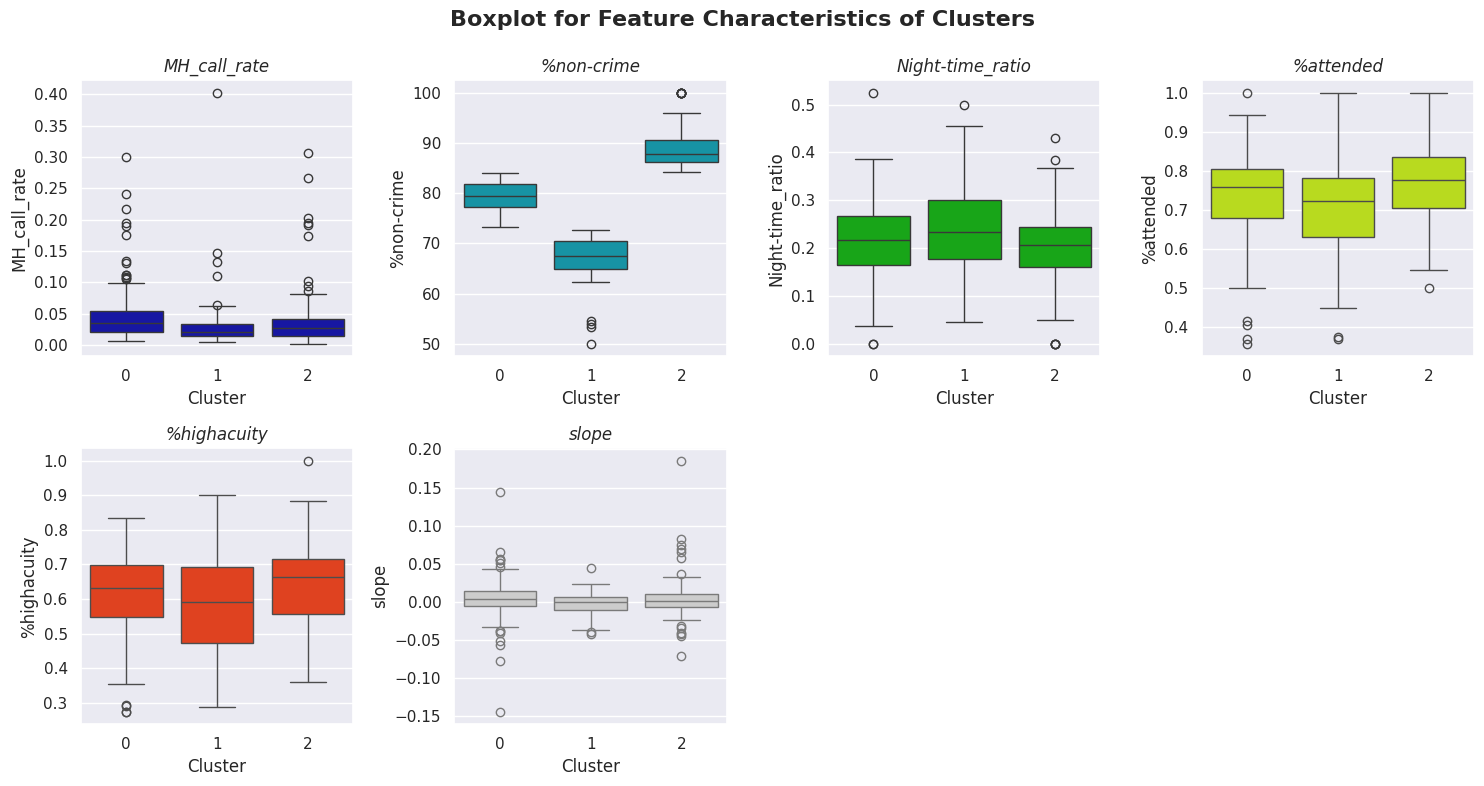

In [29]:
fig, axes = plt.subplots(nrows=int(np.ceil(num_features / 4)), ncols=4, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(cluster_means.columns):
    sns.boxplot(x='cluster_labels', y=feature, data=X,ax=axes[i], color=cm.nipy_spectral((i+1)/num_features))
    axes[i].set_ylabel(feature)
    axes[i].tick_params(axis='x', labelrotation=0)
    axes[i].set_xlabel('Cluster')
    axes[i].set_title(feature, fontstyle='italic')
    
for ax in axes.flat[cluster_means.columns.size:]:
     ax.set_axis_off()

# Set the title
fig.suptitle('Boxplot for Feature Characteristics of Clusters', fontsize=16,fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

### 3.1.1 Investigating Anomalies in the clusters

In [ ]:
!pip install data-science-utils

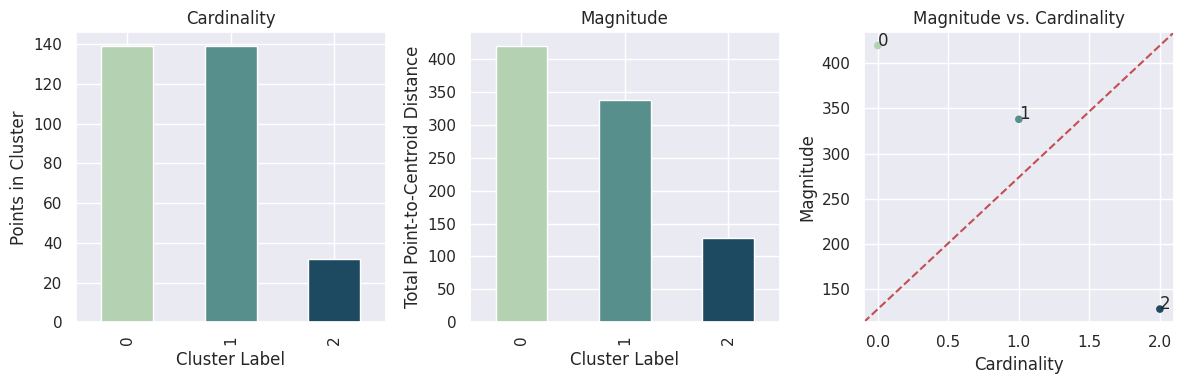

In [35]:
# Cluster diagnosis using cardinality and magnitude
from ds_utils.unsupervised import plot_cluster_cardinality, plot_cluster_magnitude, plot_magnitude_vs_cardinality
from scipy.spatial.distance import euclidean

cluster_colors = ['#b4d2b1', '#568f8b', '#1d4a60', '#cd7e59', '#ddb247', '#d15252']

fig, (ax1, ax2, ax3) = plt.subplots(1,3,figsize=(12,4))

plot_cluster_cardinality(lsoa_kmeans.labels_,
                         ax=ax1,
                         title="Cardinality",
                         color=cluster_colors
                        )
plot_cluster_magnitude(X.iloc[:,:6].values,
                       lsoa_kmeans.labels_,
                       lsoa_kmeans.cluster_centers_,
                       euclidean,
                       ax=ax2,
                       title="Magnitude",
                       color=cluster_colors
                      )
plot_magnitude_vs_cardinality(X.iloc[:,:6].values,
                              lsoa_kmeans.labels_,
                              lsoa_kmeans.cluster_centers_,
                              euclidean,
                              color=cluster_colors[0:lsoa_kmeans.n_clusters],
                              ax=ax3, 
                              title="Magnitude vs. Cardinality")

plt.tight_layout()
plt.show()

Clusters with higher cardinality also tend to have high magnitude. It is assumed that normal clusters should lie close to the 45&deg; line. Anomalies can be identified based on the distance from the <span style="color:red">**red line** </span>. In this case, **cluster 0** seemd to be lying at the highest distance from the 45&deg; line.

### 3.1.2 Cluster Visualisation in 2D space using PCA

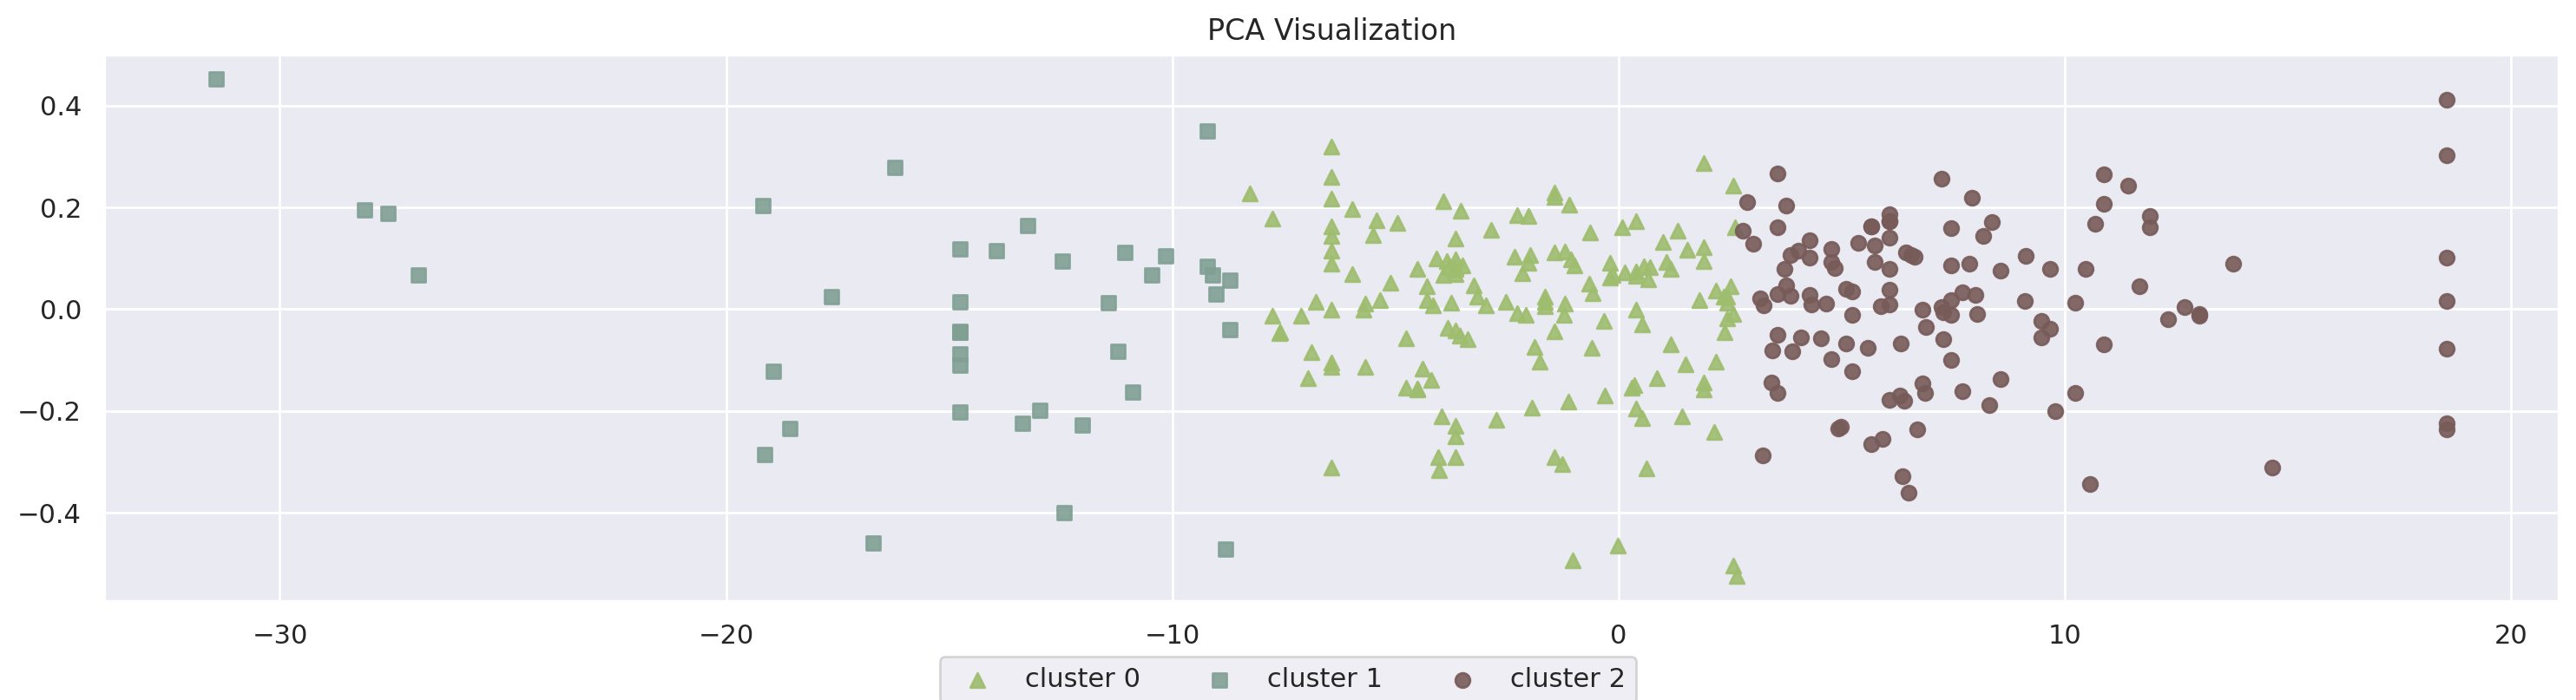

In [31]:
from sklearn.decomposition import PCA

sns.set_theme()
fig, ax = plt.subplots(figsize=(15,4), dpi=200)
cluster_colors = ['#9EBD6E','#81a094','#775b59']

# PCA
pca_scaled = PCA(n_components=2,random_state=10)
X_pca = pca_scaled.fit_transform(X.iloc[:,:6])

for l, c, m in zip(range(0, 3), cluster_colors[0:lsoa_kmeans.n_clusters], ('^', 's', 'o')):
    ax.scatter(X_pca[lsoa_kmeans.labels_ == l, 0],
                X_pca[lsoa_kmeans.labels_ == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )
ax.set_title("PCA Visualization")

labels = np.unique(lsoa_kmeans.labels_)
labels = ["cluster "+str(l) for l in labels]
fig.legend(labels, loc='lower center',ncol=len(labels), bbox_transform=(1,0),borderaxespad=-0.1)
plt.tight_layout()
plt.show()

### 3.1.3 Deviation from the mean for each feature per cluster

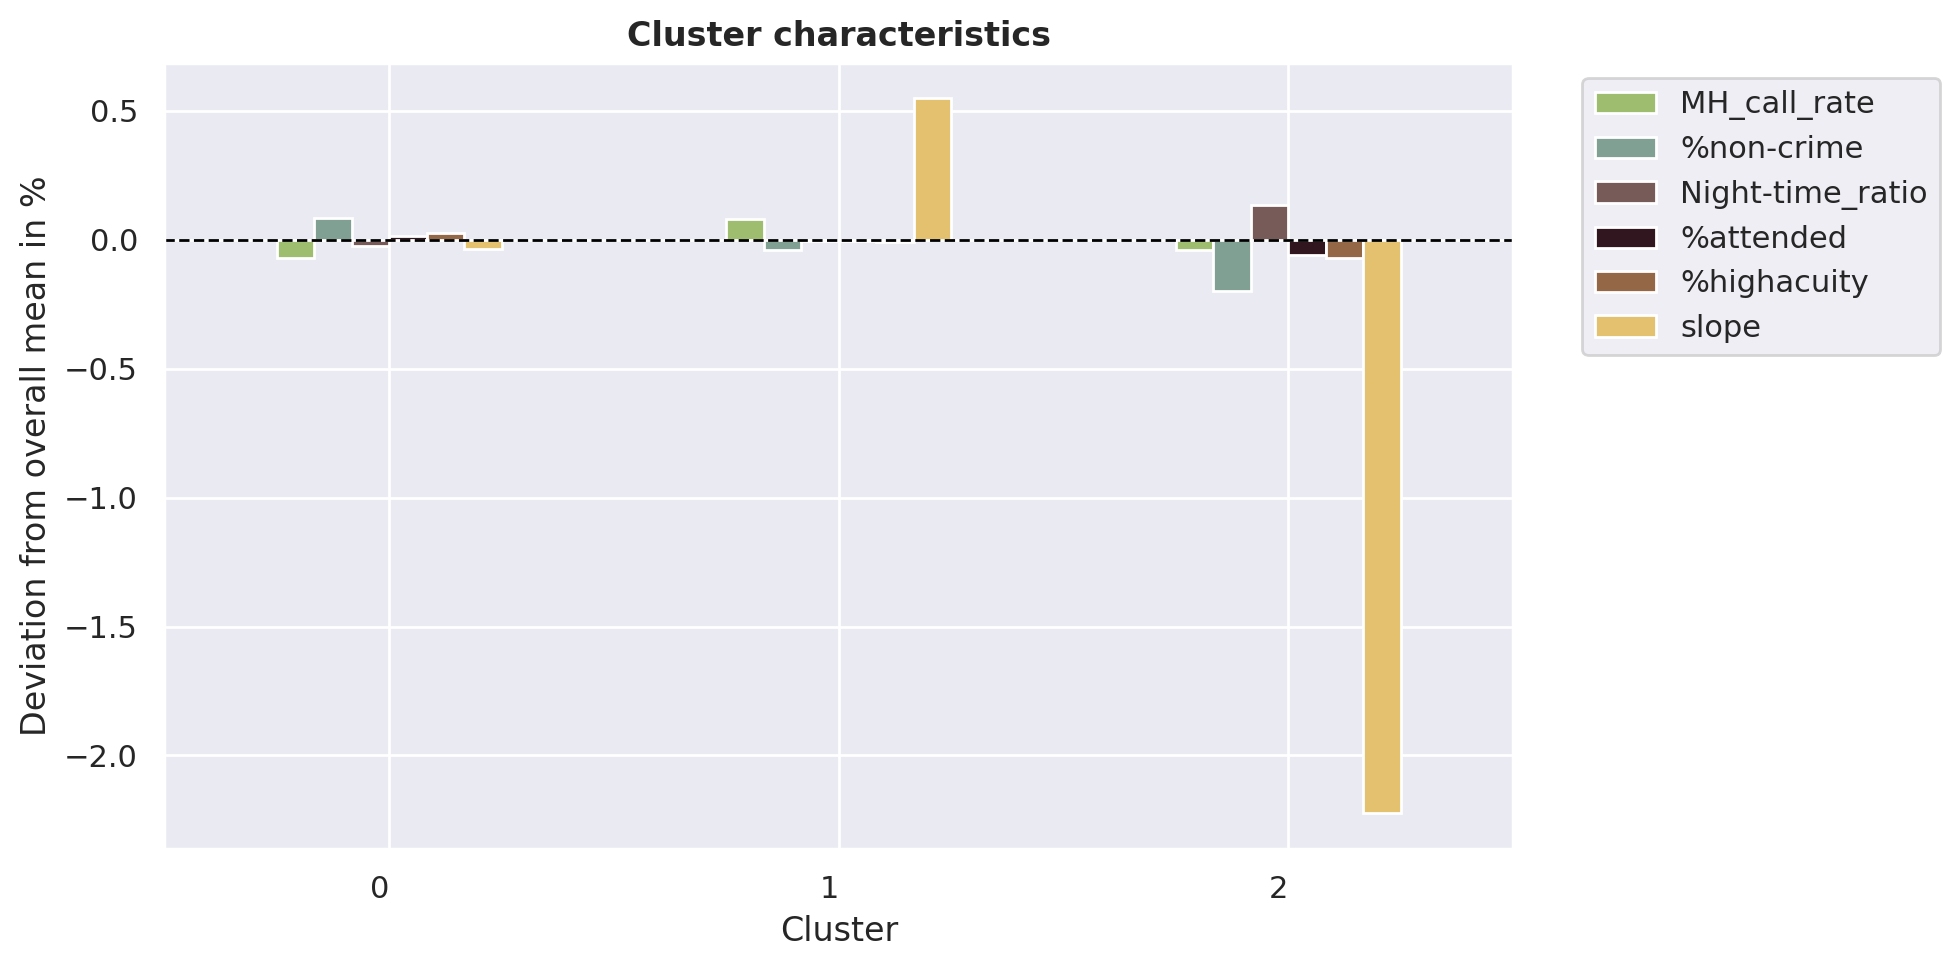

In [45]:
comeans = ['#9EBD6E','#81a094','#775b59','#32161f', '#946846', '#E3C16F', '#fe938c', '#E6B89C','#EAD2AC',
          '#DE9E36', '#4281A4','#37323E','#95818D']

X_dev_rel = (cluster_means-X.iloc[:,:6].mean())/X.iloc[:,:6].mean()
fig = plt.figure(figsize=(10,5), dpi=200)
X_dev_rel.plot(kind='bar', 
                       ax=fig.add_subplot(), 
                       title="Cluster characteristics", 
                       color=comeans,
                       xlabel="Cluster",
                       ylabel="Deviation from overall mean in %"
                      )
plt.axhline(y=0, linewidth=1, ls='--', color='black')
plt.legend(bbox_to_anchor=(1.04,1))

plt.title("Cluster characteristics",fontweight='bold')

fig.autofmt_xdate(rotation=0)
plt.tight_layout()
plt.show()

In [38]:
X_norm = X.set_index('cluster_labels')
X_norm['%non-crime'] = X_norm['%non-crime']/100
# Apply z-score normalization
X_normalized = X_norm.apply(zscore)

### 3.1.4 Radar Plot

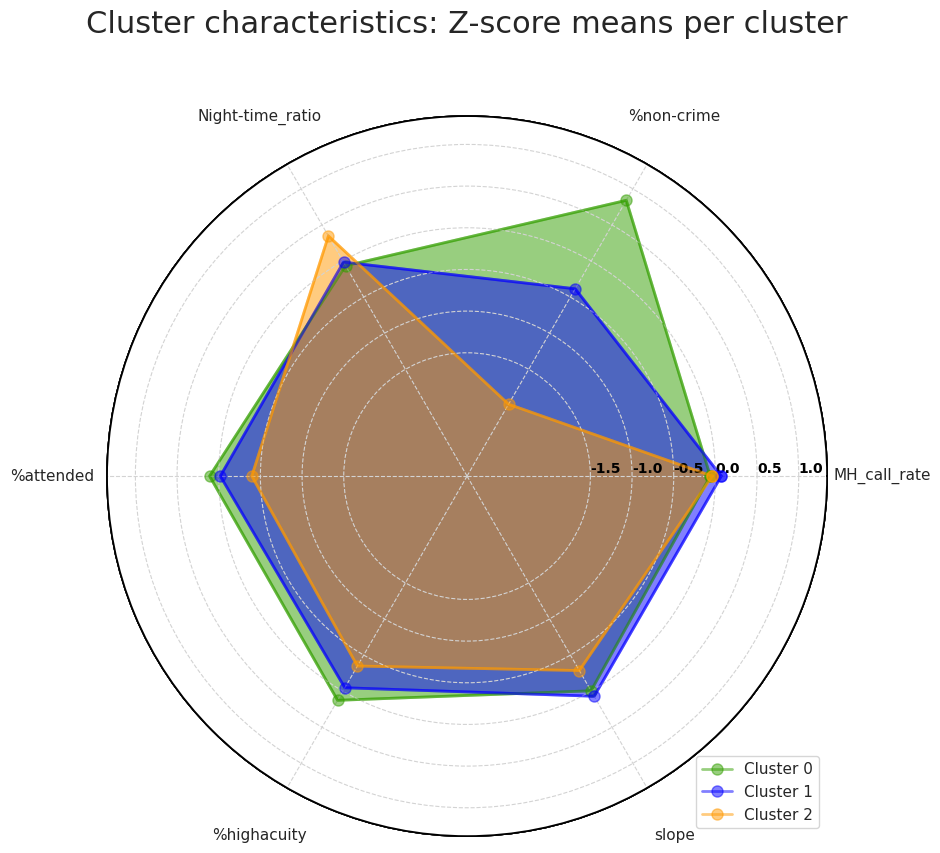

In [39]:
class Radar(object):
    # https://medium.com/@reinapeh/creating-a-complex-radar-chart-with-python-31c5cc4b3c5c
    def __init__(self, figure, title, labels, rect=None):
        if rect is None:
            rect = [0.05, 0.05, 0.9, 0.9]

        self.n = len(title)
        self.angles = np.arange(0, 360, 360.0/self.n)
        
        self.axes = [figure.add_axes(rect, projection='polar', label='axes%d' % i) for i in range(self.n)]
        self.ax = self.axes[0]
        self.ax.set_thetagrids(self.angles,labels=[])
        for angle, label in zip(self.angles, title):
            angle_rad = np.deg2rad(angle)
            self.ax.text(
                angle_rad, 2.0,  # outside the radar circle
                label,
                ha='center',
                va='center',
                fontsize=11,
                fontname="DejaVu Sans",
                zorder=9
            )
        # self.ax.set_thetagrids(self.angles, labels=title, fontsize=11,fontname="DejaVu Sans", zorder=0) # Feature names
        self.ax.set_yticklabels([])
        
        for ax in self.axes[1:]:
            ax.xaxis.set_visible(False)
            ax.set_yticklabels([])
            ax.set_zorder(-99)

        for ax, angle, label in zip(self.axes, self.angles, labels):
            ax.spines['polar'].set_color('black')
            ax.spines['polar'].set_zorder(99)
                     
    def plot(self, values, *args, **kw):
        angle = np.deg2rad(np.r_[self.angles, self.angles[0]])
        values = np.r_[values, values[0]]
        self.ax.plot(angle, values,marker='o', markersize=8,*args, **kw)
        kw['label'] = '_noLabel'
        self.ax.fill(angle, values,zorder=-99,*args,**kw)


sns.set_theme(style='white')

fig = plt.figure(figsize=(8, 8))
no_features = len(lsoa_kmeans.feature_names_in_)
radar = Radar(fig, lsoa_kmeans.feature_names_in_, np.unique(lsoa_kmeans.labels_))
color_set = ['#339F00', '#0500FF', '#FF9900']
max_zval = []
min_zval = []

for k in range(0,lsoa_kmeans.n_clusters):
    cluster_data = X_normalized.loc[k].mean().values.tolist()
    max_zval.append(max(X_normalized.loc[k].mean()))
    min_zval.append(min(X_normalized.loc[k].mean()))
    radar.plot(cluster_data,  '-', lw=2, color=color_set[k], alpha=0.5, label='Cluster {}'.format(k))

min_zval = [round(i,2) for i in min_zval]
max_zval = [round(i,2) for i in max_zval]
y_tick_vals = [-1.5,-1.0,-0.5,0.0,0.5,1.0,1.5]

radar.ax.legend()
radar.ax.set_yticks(y_tick_vals)
radar.ax.set_yticklabels([str(z) for z in y_tick_vals], color="black", size=10,fontname="DejaVu Sans",fontweight='bold')
radar.ax.set_rlabel_position(0)
radar.ax.grid(color='lightgray', linestyle='--', linewidth=0.8)

radar.ax.set_ylim(min(min_zval)-1,max(max_zval)+0.5)
radar.ax.set_title("Cluster characteristics: Z-score means per cluster", size=22, pad=60)
plt.show()

### 3.1.5 Geo-spatial visualisation of clusters

In [66]:
from shapely.wkt import loads

X_geo = X.merge(df_indicators['geometry'],left_index=True,right_index=True)
X_geo['geometry'] = X_geo['geometry'].apply(loads)
X_gdf = gpd.GeoDataFrame(X_geo,geometry='geometry',crs='EPSG:4326')

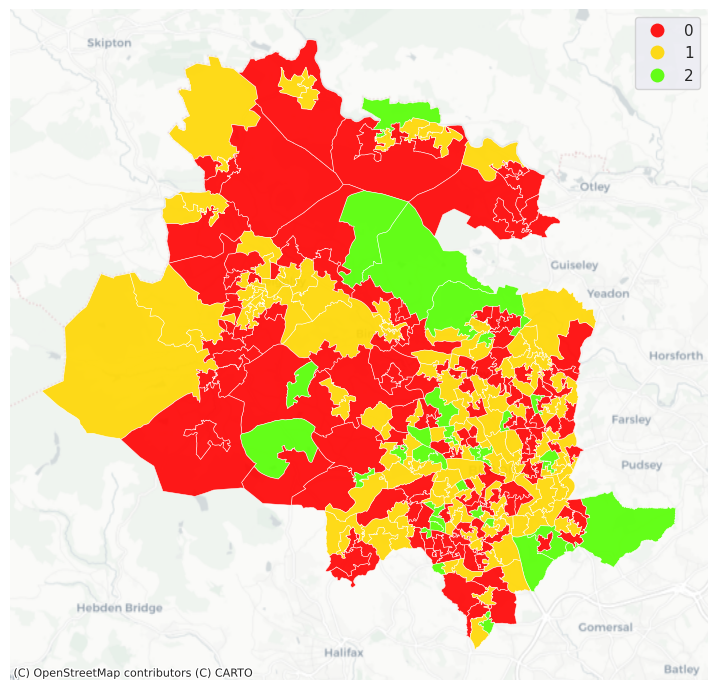

In [67]:
# Ensure 'cluster_labels' is treated as a categorical variable
X_gdf['cluster_labels'] = X_gdf['cluster_labels'].astype('category')

fig, ax = plt.subplots(1, figsize=(9, 9))
# Build map
X_gdf.plot(
    column='cluster_labels',
    cmap="prism",
    k=5,
    edgecolor="white",
    linewidth=0.4,
    alpha=0.9,
    legend=True,
    ax=ax,
)
# Add basemap
contextily.add_basemap(
    ax,
    crs=X_gdf.crs,
    source=contextily.providers.CartoDB.Positron,
)
# Remove axes
ax.set_axis_off()

In [ ]:
# Function for normalising the ranks of each indicator
def rank_norming(new_df,old_df,new_col_name,old_col_name):
    # Step 1: Rank the Scores
    new_df[new_col_name] = old_df[old_col_name].rank(pct=True)

    # # Step 2: Normalise the Ranks to Percentile Rank
    # new_df[new_col_name] = (new_df[new_col_name] - 1) / (len(new_df) - 1) * 100

    return new_df[new_col_name]

def zscore_norming(new_df,old_df,new_col_name,old_col_name):
    # Step 1: Z-Scores Normalisation
    new_df[new_col_name] = (old_df[old_col_name]-old_df[old_col_name].mean())/old_df[old_col_name].std()

    return new_df[new_col_name]

In [ ]:
X_norm = pd.DataFrame(np.zeros(X.shape[0]))

In [ ]:
for i in X.iloc[:,0:8].columns:
    X_norm[i+str('-norm')] = rank_norming(X_rank,X.reset_index(),i+str('-norm'),i) # reset index to avoid nan values

In [ ]:
X_norm.drop(0,axis=1,inplace=True)

In [ ]:
distortions = []
inertias = []
map_distortion = {}
map_inertia = {}

for k in range(1, 10):
    kmeanModel = KMeans(n_clusters=k, init= 'k-means++',random_state=42).fit(X_norm)    
    distortions.append(sum(np.min(cdist(X_norm, kmeanModel.cluster_centers_, 'euclidean'), axis=1)**2) / X_norm.shape[0])    
    inertias.append(kmeanModel.inertia_)
    
    map_distortion[k] = distortions[-1]
    map_inertia[k] = inertias[-1]
    
sns.set_theme()
print("Distortion values:")
for key, val in map_distortion.items():
    print(f'{key} : {val}')

plt.plot(range(1, 10), distortions, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Distortion')
plt.title('The Elbow Method using Distortion')
plt.show()

print("Inertia values:")
for key, val in map_inertia.items():
    print(f'{key} : {val}')

plt.plot(range(1, 10), inertias, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method using Inertia')
plt.show()

In [ ]:
for n_clusters in range(2, 10):
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    cluster = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = cluster.fit_predict(X_rank)

    silhouette_avg = silhouette_score(X_rank, cluster_labels)   

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X_rank, cluster_labels)

    y_lower = 20
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        X_rank.iloc[:, 0], X_rank.iloc[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # Labeling the clusters
    centers = cluster.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d\n score: %.4f"
        % (n_clusters,silhouette_avg),
        fontsize=14,
        fontweight="bold",
    )

plt.show()

## 3.2 K-Medoids

In [73]:
from sklearn_extra.cluster import KMedoids

In [129]:
# X = df_explore[['MH_call_rate','%non-crime', 'Night-time_ratio', 'Temporalvolatility(CV)', '%attended', '%highacuity', 'slope','lsoa_lq', 'Percentage change']]
X = df_explore[['MH_call_rate','%non-crime', 'Night-time_ratio', '%attended', '%highacuity', 'slope']]
X.head(2)

,MH_call_rate,%non-crime,Night-time_ratio,%attended,%highacuity,slope
0,0.029668,96.078431,0.215686,0.607843,0.372549,0.006048
1,0.052961,81.720430,0.193548,0.655914,0.494624,0.001164


Distortion values:
1 : 65.92750495795255
2 : 29.06817726990957
3 : 24.876528887658804
4 : 10.096757408788301
5 : 7.073598204544688
6 : 4.747880898792558
7 : 3.3340192416467413
8 : 2.2824603773505125
9 : 2.804425856451404


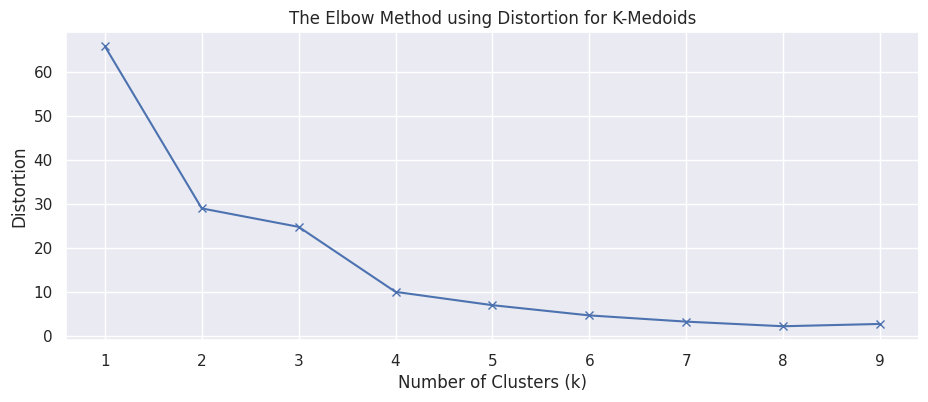

Inertia values:
1 : 1930.2513818109821
2 : 1137.7257451037801
3 : 1036.145346645882
4 : 664.6380902288486
5 : 581.6994156981399
6 : 523.8997100395069
7 : 424.14640837288954
8 : 372.7967815069892
9 : 361.07616356117046


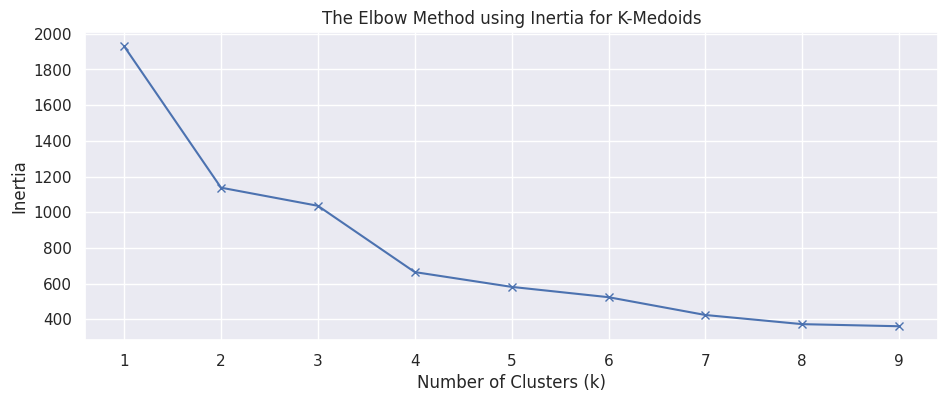

In [130]:
distortions = []
inertias = []
map_distortion = {}
map_inertia = {}

for k in range(1, 10):
    kmedoidsModel =KMedoids(n_clusters=k,metric='euclidean',init='k-medoids++', max_iter=300, random_state=None).fit(X)    
    distortions.append(sum(np.min(cdist(X, kmedoidsModel.cluster_centers_, 'euclidean'), axis=1)**2) / X.shape[0])    
    inertias.append(kmedoidsModel.inertia_)
    
    map_distortion[k] = distortions[-1]
    map_inertia[k] = inertias[-1]
    
sns.set_theme()
print("Distortion values:")
for key, val in map_distortion.items():
    print(f'{key} : {val}')

plt.plot(range(1, 10), distortions, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Distortion')
plt.title('The Elbow Method using Distortion for K-Medoids')
plt.show()

print("Inertia values:")
for key, val in map_inertia.items():
    print(f'{key} : {val}')

plt.plot(range(1, 10), inertias, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method using Inertia for K-Medoids')
plt.show()

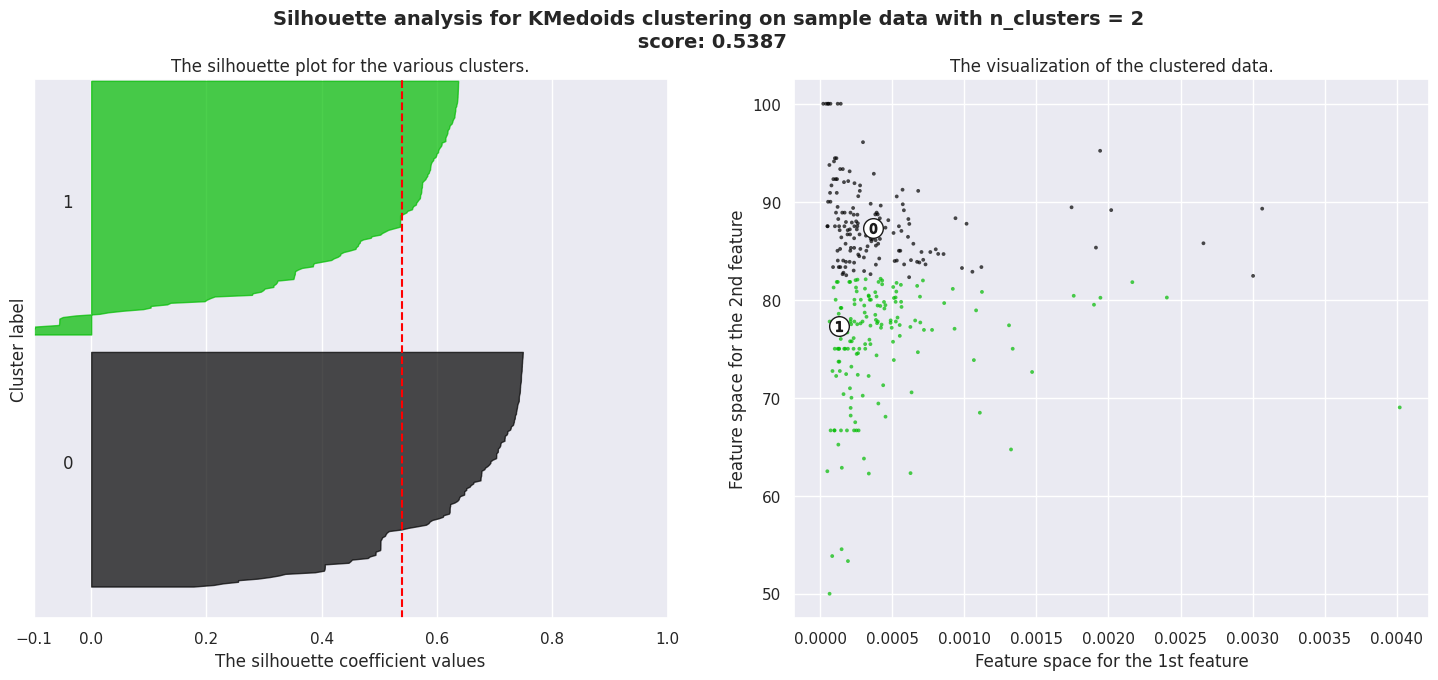

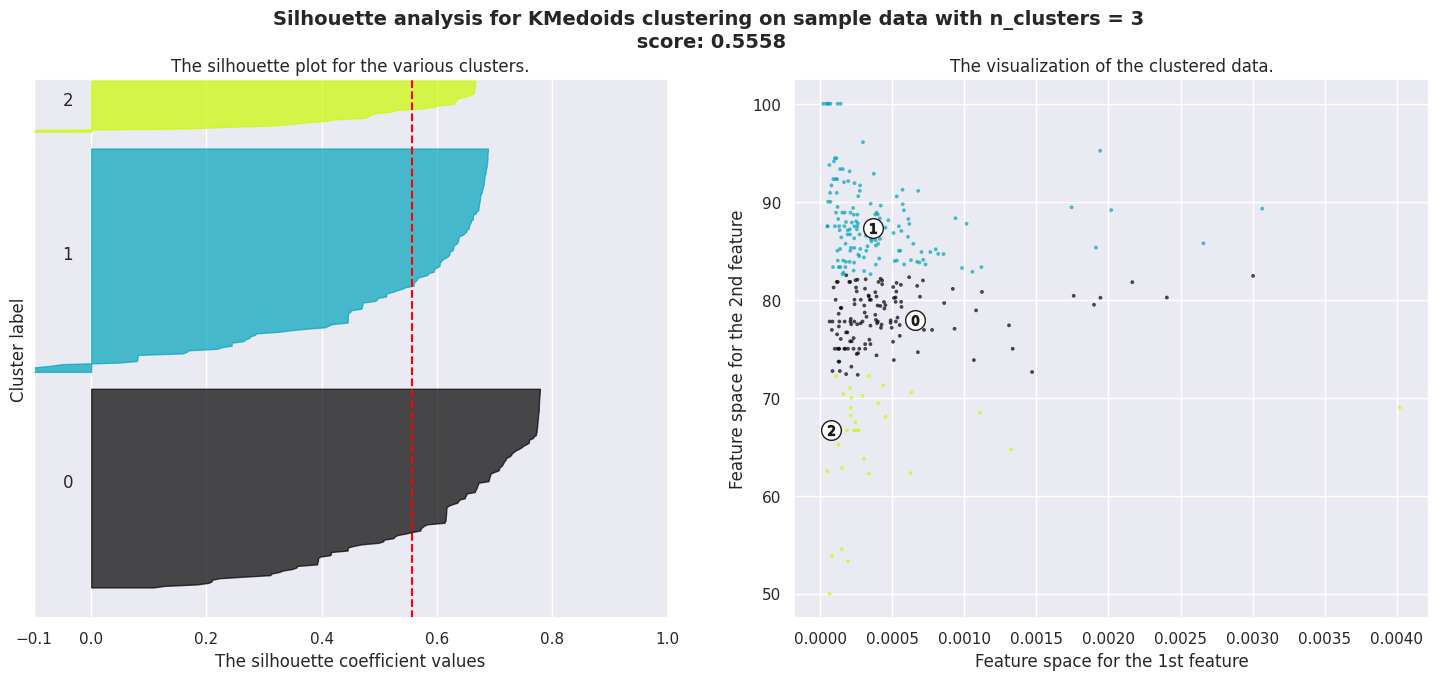

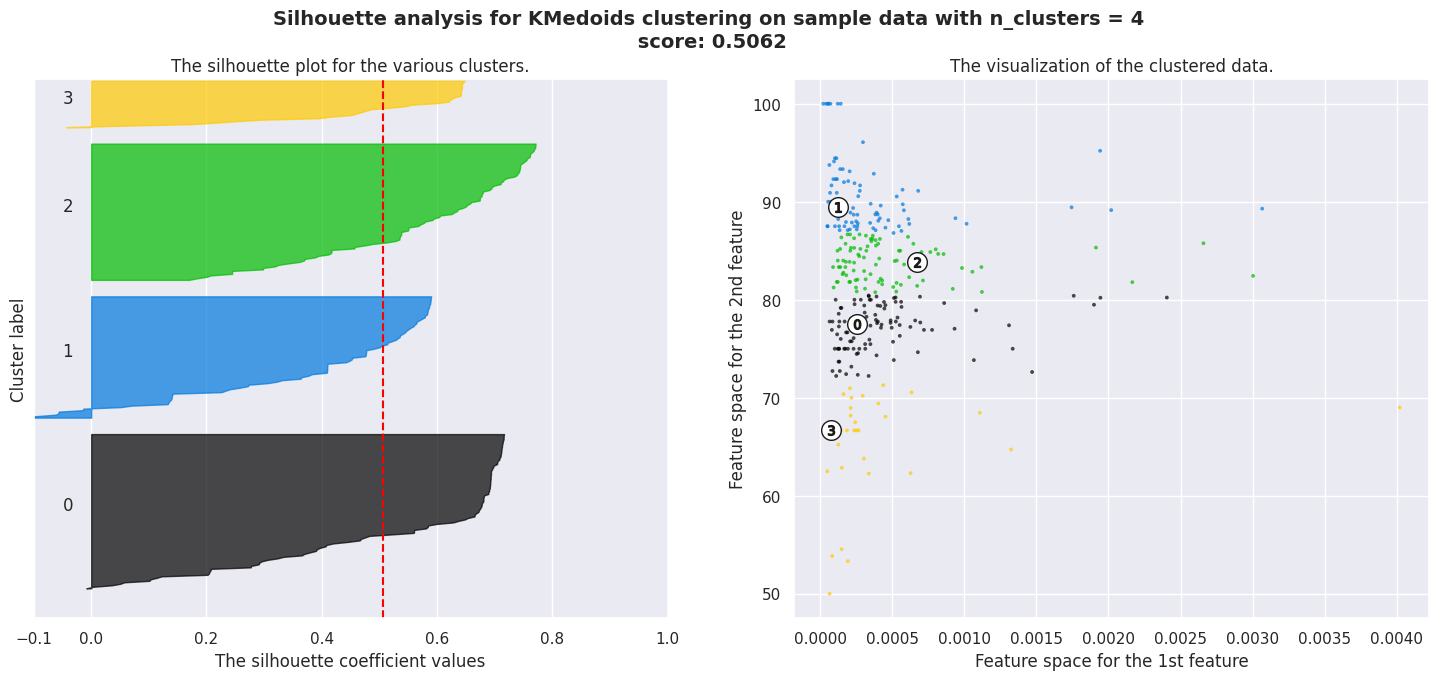

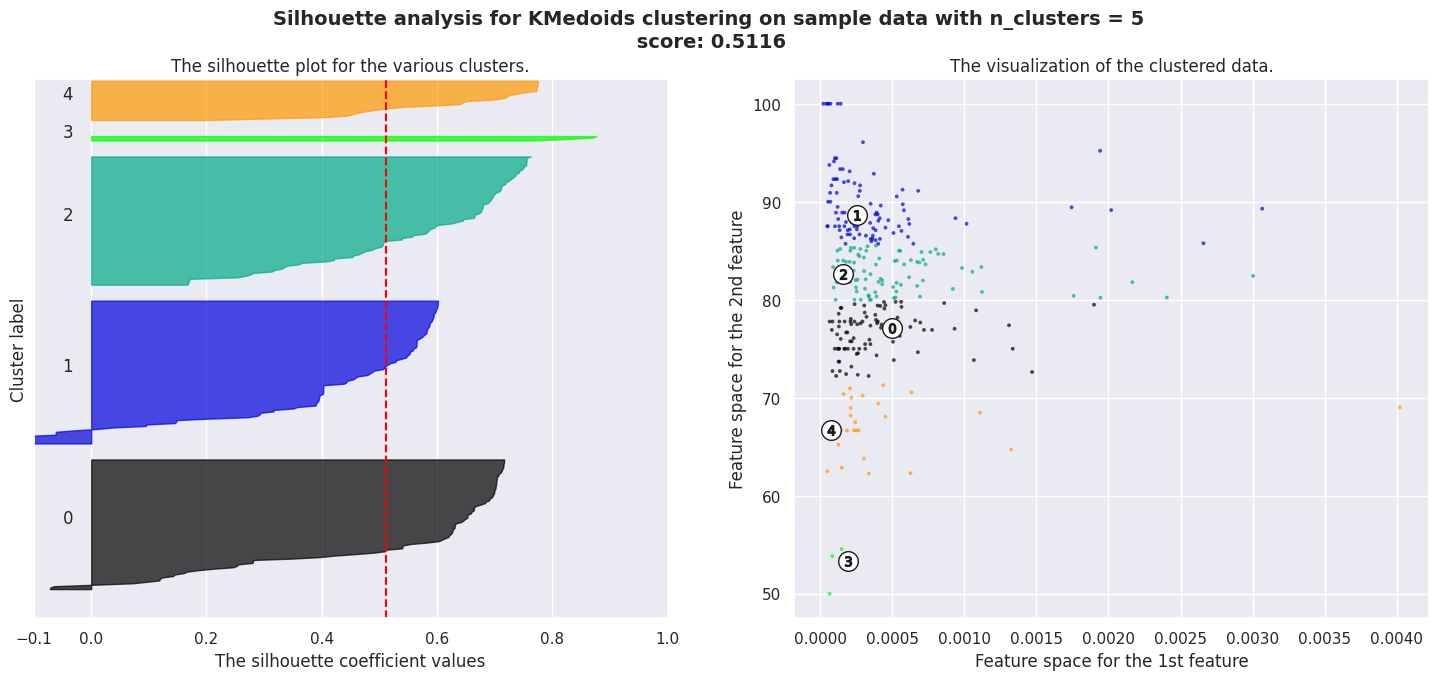

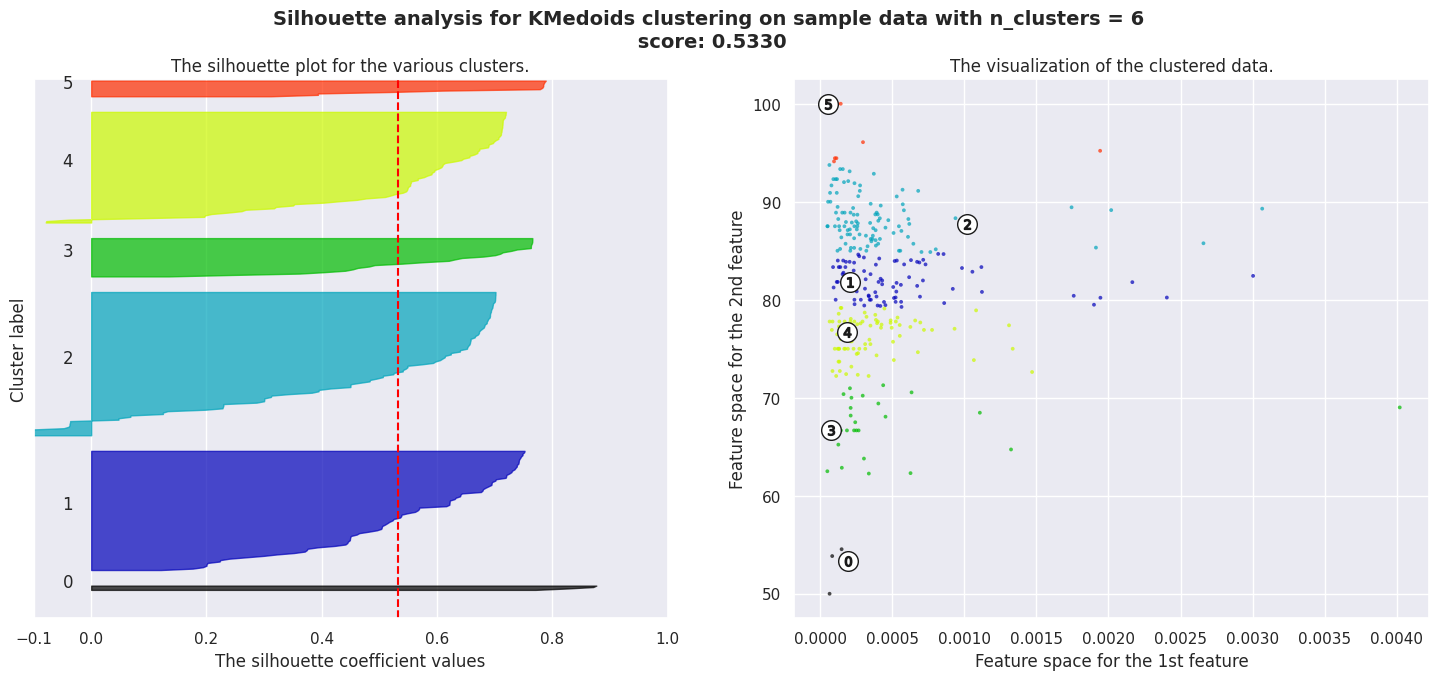

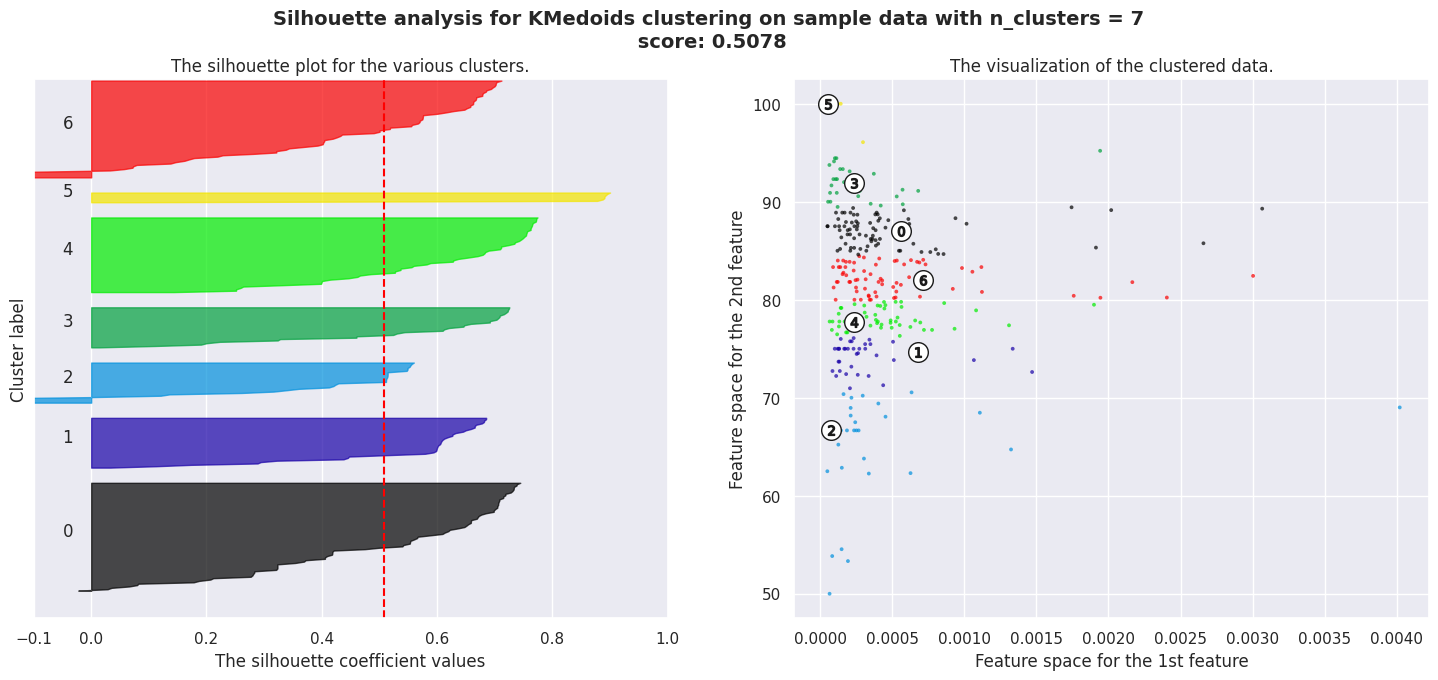

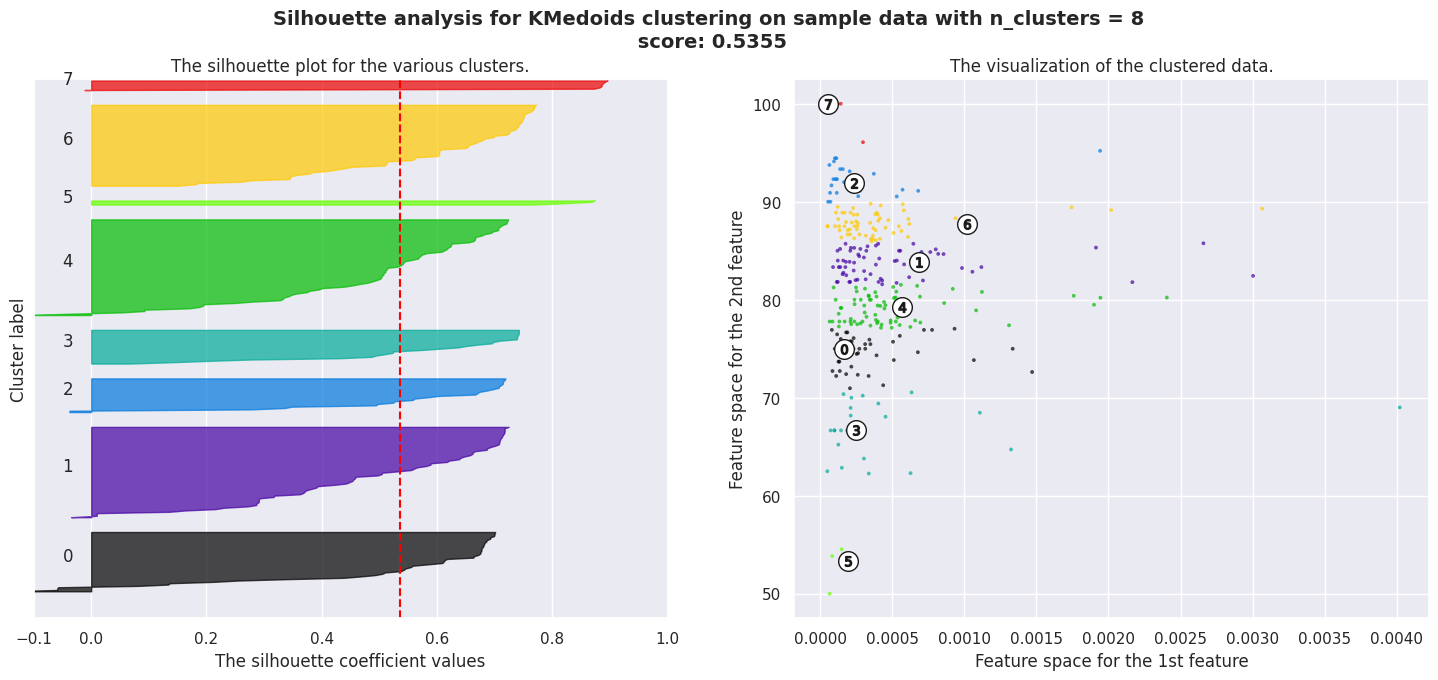

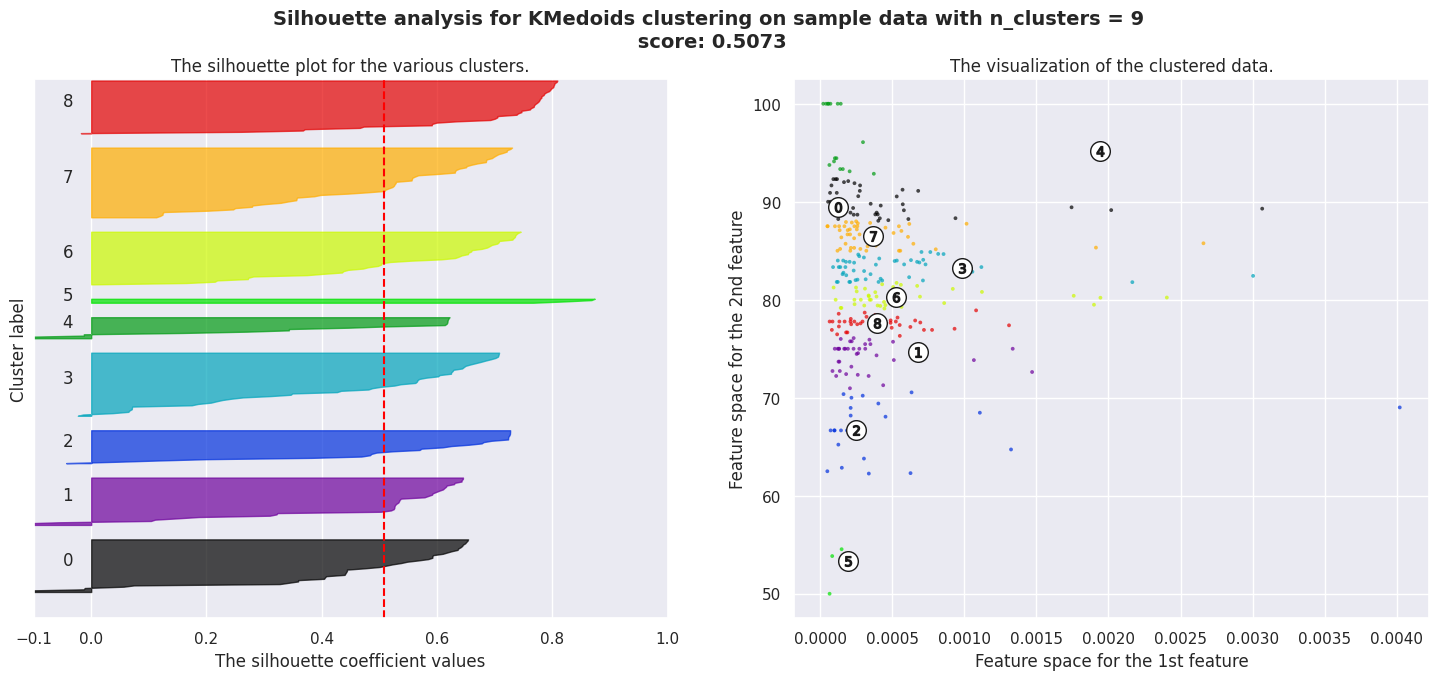

In [131]:
silhouette_scores =[]
for n_clusters in range(2, 10):
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    cluster = KMedoids(n_clusters=n_clusters,metric='euclidean',init='k-medoids++', max_iter=300, random_state=None)
    cluster_labels = cluster.fit_predict(X)

    silhouette_avg = silhouette_score(X, cluster_labels)
    silhouette_scores.append(silhouette_avg)

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 20
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        X.iloc[:, 0]/100, X.iloc[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # Labeling the clusters
    centers = cluster.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0]/100,
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0]/100, c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMedoids clustering on sample data with n_clusters = %d\n score: %.4f"
        % (n_clusters,silhouette_avg),
        fontsize=14,
        fontweight="bold",
    )

plt.show()

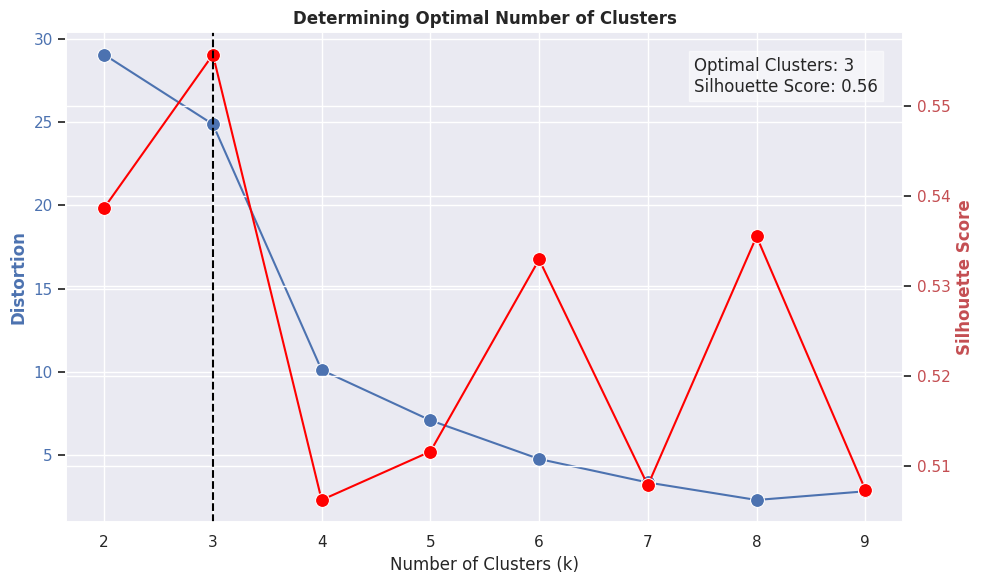

In [132]:
sns.set_theme()

cluster_range = np.arange(2,10)

filtered_scores = [score for i, score in enumerate(silhouette_scores) if cluster_range[i] <=5]

optimal_clusters = cluster_range[filtered_scores.index(max(filtered_scores))]
optimal_score = max(filtered_scores)

fig, ax1 = plt.subplots(figsize=(10,6))

sns.lineplot(x=cluster_range, y=distortions[1:],ax=ax1, marker='o',markersize=10)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Distortion', color='b',fontweight='bold')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
sns.lineplot(x=cluster_range, y=silhouette_scores,ax=ax2, color='red',marker='o',markersize=10)
ax2.set_ylabel('Silhouette Score', color='r',fontweight='bold')
ax2.tick_params(axis='y', labelcolor='r')

plt.axvline(x=optimal_clusters, color='black', linestyle='--')
plt.text(0.75, 0.95, f'Optimal Clusters: {optimal_clusters}\nSilhouette Score: {optimal_score:.2f}', 
            horizontalalignment='left', verticalalignment='top', transform=plt.gca().transAxes, 
            bbox=dict(facecolor='white', alpha=0.5))

plt.title('Determining Optimal Number of Clusters',fontweight='bold')

plt.tight_layout()
plt.show()

In [90]:
X.drop('cluster_labels_kmedoids',axis=1,inplace=True)

In [133]:
model = KMedoids(n_clusters=3,metric='euclidean',init='k-medoids++', max_iter=300, random_state=None) 
lsoa_kmeans = model.fit(X)

X['cluster_labels_kmedoids'] = lsoa_kmeans.labels_

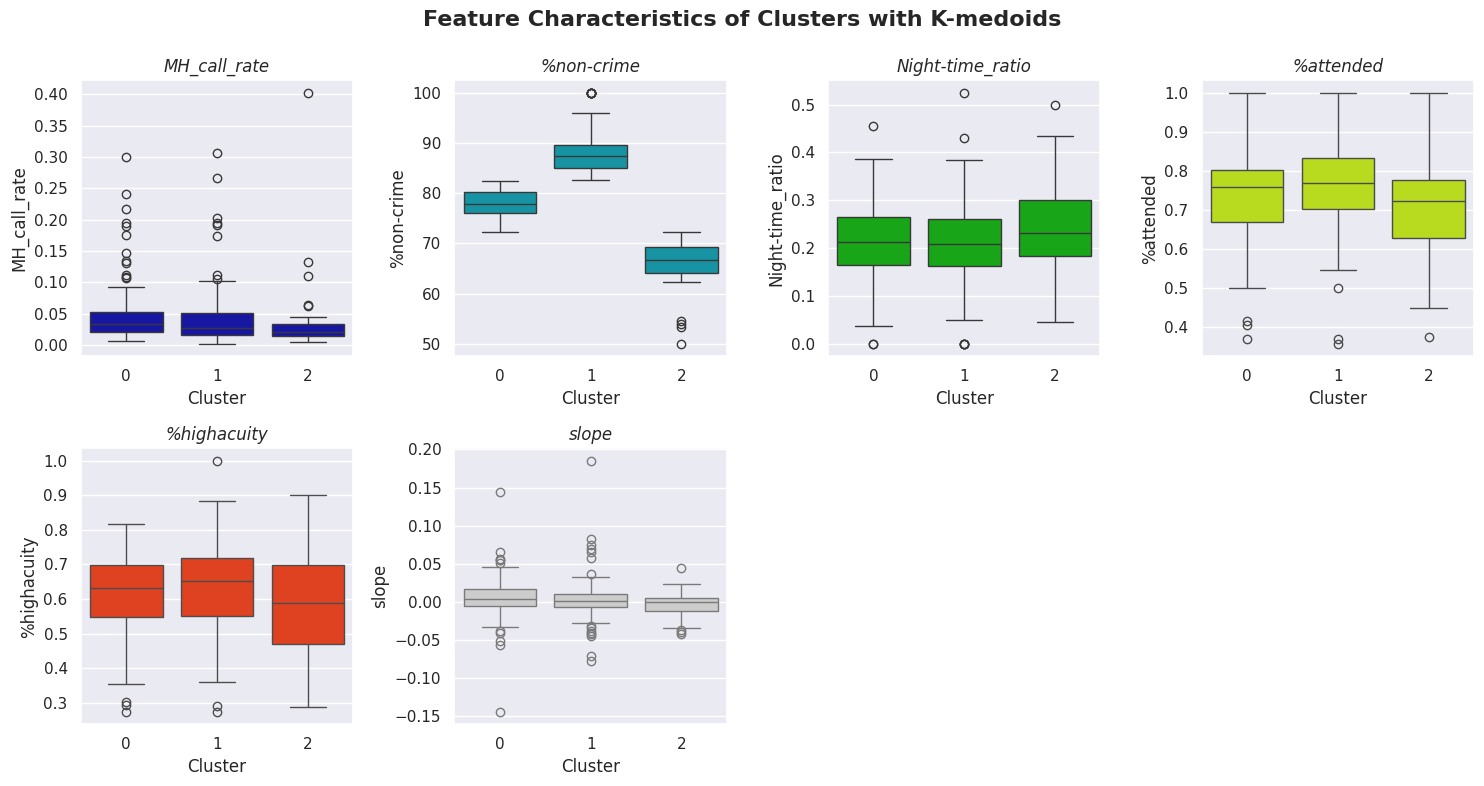

In [134]:
# Calculate the average value of each feature for each cluster
cluster_means = X.groupby('cluster_labels_kmedoids').mean()
num_features = len(cluster_means.columns)

fig, axes = plt.subplots(nrows=int(np.ceil(num_features / 4)), ncols=4, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(cluster_means.columns):
    sns.boxplot(x='cluster_labels_kmedoids', y=feature, data=X,ax=axes[i], color=cm.nipy_spectral((i+1)/num_features))
    # cluster_means[feature].plot(kind='bar', ax=axes[i], title=feature,color=cm.nipy_spectral(i/num_features))
    axes[i].set_ylabel(feature)
    axes[i].tick_params(axis='x', labelrotation=0)
    axes[i].set_xlabel('Cluster')
    axes[i].set_title(feature, fontstyle='italic')
    
for ax in axes.flat[cluster_means.columns.size:]:
     ax.set_axis_off()

# Set the title
fig.suptitle('Feature Characteristics of Clusters with K-medoids', fontsize=16,fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

### 3.2.1 Investigating Anomalies in the clusters

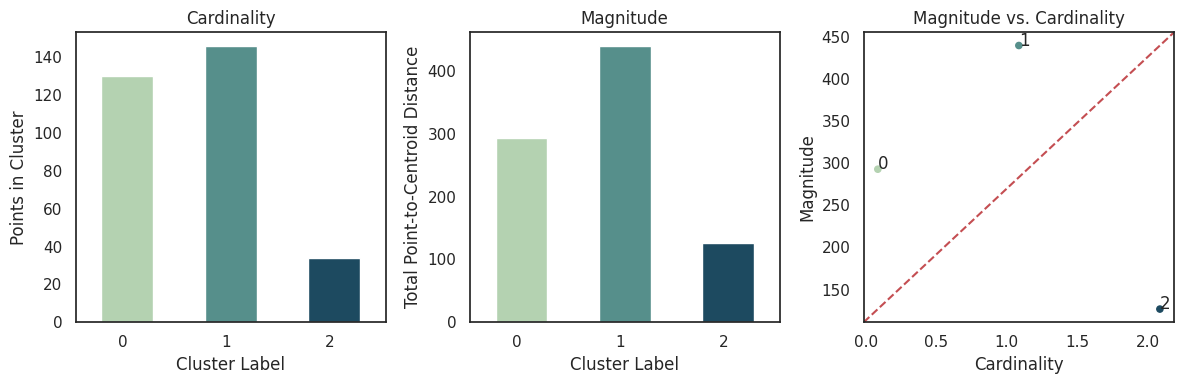

In [144]:
# Cluster diagnosis using cardinality and magnitude
from ds_utils.unsupervised import plot_cluster_cardinality, plot_cluster_magnitude, plot_magnitude_vs_cardinality
from scipy.spatial.distance import euclidean

cluster_colors = ['#b4d2b1', '#568f8b', '#1d4a60', '#cd7e59', '#ddb247', '#d15252','#DE9E36', '#4281A4','#37323E','#95818D']

fig, (ax1, ax2, ax3) = plt.subplots(1,3,figsize=(12,4))

plot_cluster_cardinality(lsoa_kmeans.labels_,
                         ax=ax1,
                         title="Cardinality",
                         color=cluster_colors
                        )
plot_cluster_magnitude(X.iloc[:,:6].values,
                       lsoa_kmeans.labels_,
                       lsoa_kmeans.cluster_centers_,
                       euclidean,
                       ax=ax2,
                       title="Magnitude",
                       color=cluster_colors
                      )
plot_magnitude_vs_cardinality(X.iloc[:,:6].values,
                              lsoa_kmeans.labels_,
                              lsoa_kmeans.cluster_centers_,
                              euclidean,
                              color=cluster_colors[0:lsoa_kmeans.n_clusters],
                              ax=ax3, 
                              title="Magnitude vs. Cardinality")

fig.autofmt_xdate(rotation=0)
plt.tight_layout()
plt.show()

### 3.2.2 Cluster Visualisation in 2D space using PCA

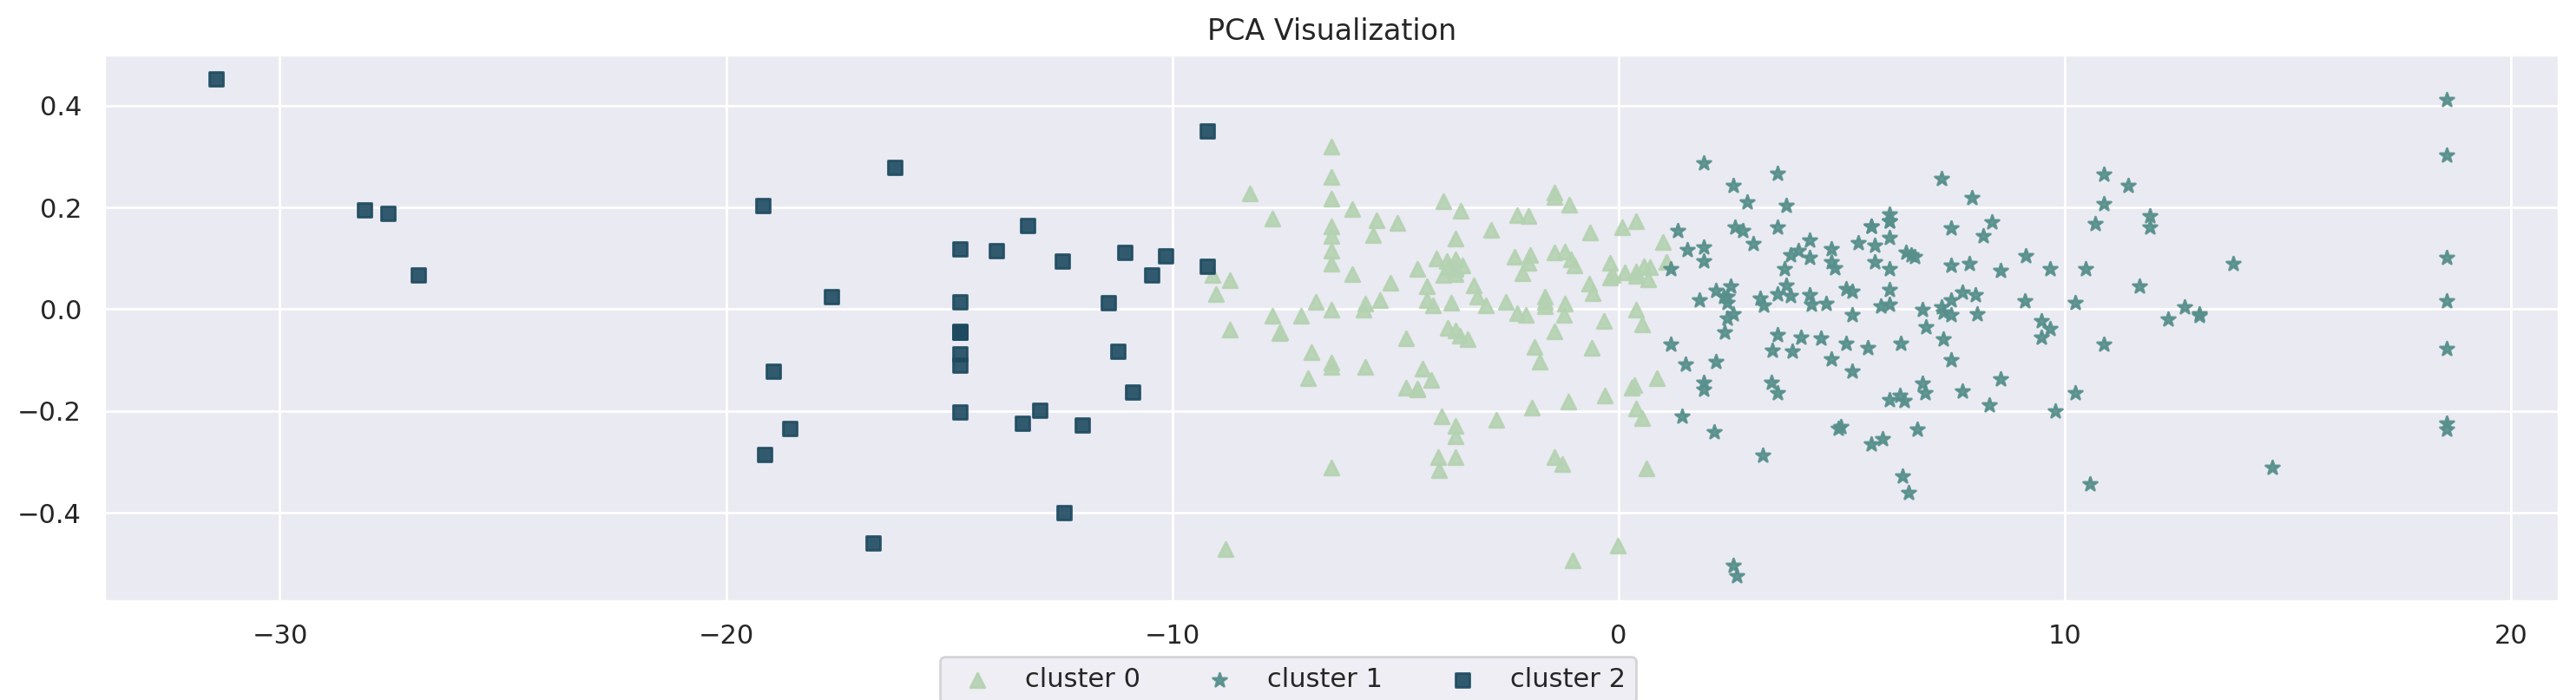

In [136]:
fig, ax = plt.subplots(figsize=(15,4), dpi=200)

# PCA
pca_scaled = PCA(n_components=2,random_state=10)
X_pca = pca_scaled.fit_transform(X.iloc[:,:6])

for l, c, m in zip(range(0, 9), cluster_colors[0:(lsoa_kmeans.n_clusters)], ('^','*', 's', 'o','D','d','.','>','X')):
    ax.scatter(X_pca[lsoa_kmeans.labels_ == l, 0],
                X_pca[lsoa_kmeans.labels_ == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )
ax.set_title("PCA Visualization")

labels = np.unique(lsoa_kmeans.labels_)
labels = ["cluster "+str(l) for l in labels]
fig.legend(labels, loc='lower center',ncol=len(labels), bbox_transform=(1,0),borderaxespad=-0.1)
plt.tight_layout()
plt.show()

### 3.2.3 Deviation from the mean for each feature per cluster

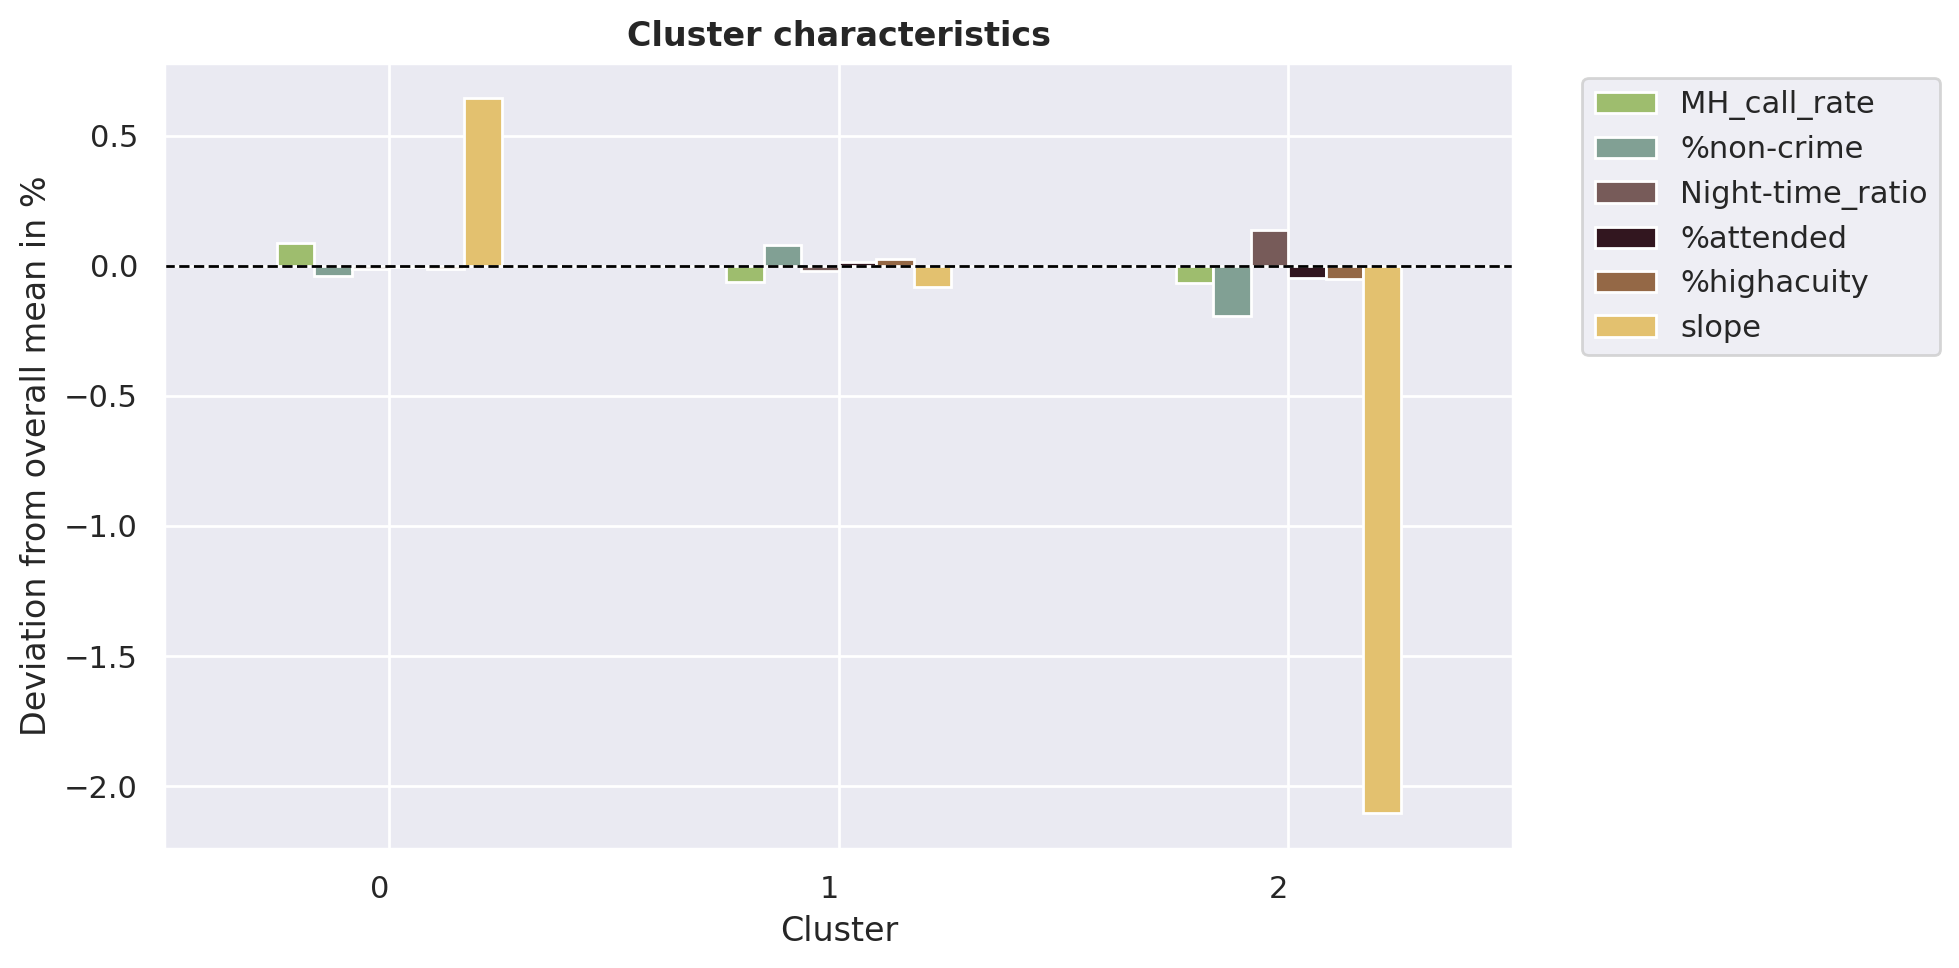

In [137]:
comeans = ['#9EBD6E','#81a094','#775b59','#32161f', '#946846', '#E3C16F', '#fe938c', '#E6B89C','#EAD2AC',
          '#DE9E36', '#4281A4','#37323E','#95818D']

X_dev_rel = (cluster_means-X.iloc[:,:6].mean())/X.iloc[:,:6].mean()
fig = plt.figure(figsize=(10,5), dpi=200)
X_dev_rel.plot(kind='bar', 
                       ax=fig.add_subplot(), 
                       title="Cluster characteristics", 
                       color=comeans,
                       xlabel="Cluster",
                       ylabel="Deviation from overall mean in %"
                      )
plt.axhline(y=0, linewidth=1, ls='--', color='black')
plt.legend(bbox_to_anchor=(1.04,1))

plt.title("Cluster characteristics",fontweight='bold')

fig.autofmt_xdate(rotation=0)
plt.tight_layout()
plt.show()

### 3.2.4 Radar Plot

In [138]:
X_norm = X.set_index('cluster_labels_kmedoids')
X_norm['%non-crime'] = X_norm['%non-crime']/100
# Apply z-score normalization
X_normalized = X_norm.apply(zscore)

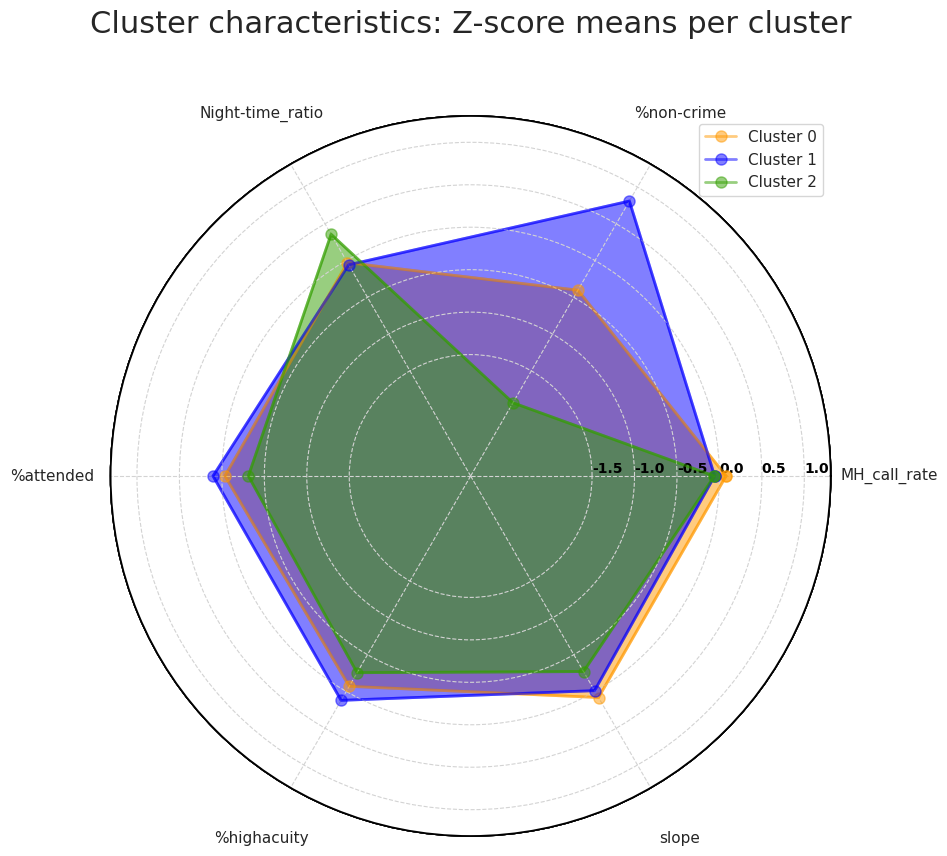

In [141]:
sns.set_theme(style='white')

fig = plt.figure(figsize=(8, 8))
no_features = lsoa_kmeans.n_features_in_
radar = Radar(fig, X.iloc[:,:6].columns, np.unique(lsoa_kmeans.labels_))
color_set = ['#339F00', '#0500FF', '#FF9900']
max_zval = []
min_zval = []

for k in range(0,lsoa_kmeans.n_clusters):
    cluster_data = X_normalized.loc[k].mean().values.tolist()
    max_zval.append(max(X_normalized.loc[k].mean()))
    min_zval.append(min(X_normalized.loc[k].mean()))
    radar.plot(cluster_data,  '-', lw=2, color=color_set[::-1][k], alpha=0.5, label='Cluster {}'.format(k))

min_zval = [round(i,2) for i in min_zval]
max_zval = [round(i,2) for i in max_zval]
y_tick_vals = [-1.5,-1.0,-0.5,0.0,0.5,1.0,1.5]

radar.ax.legend()
radar.ax.set_yticks(y_tick_vals)
radar.ax.set_yticklabels([str(z) for z in y_tick_vals], color="black", size=10,fontname="DejaVu Sans",fontweight='bold')
radar.ax.set_rlabel_position(0)
radar.ax.grid(color='lightgray', linestyle='--', linewidth=0.8)

radar.ax.set_ylim(min(min_zval)-1,max(max_zval)+0.5)
radar.ax.set_title("Cluster characteristics: Z-score means per cluster", size=22, pad=60)
plt.show()

### 3.2.5 Geo-spatial visualisation of clusters

In [142]:
X_geo = X.merge(df_indicators['geometry'],left_index=True,right_index=True)
X_geo['geometry'] = X_geo['geometry'].apply(loads)
X_gdf = gpd.GeoDataFrame(X_geo,geometry='geometry',crs='EPSG:4326')

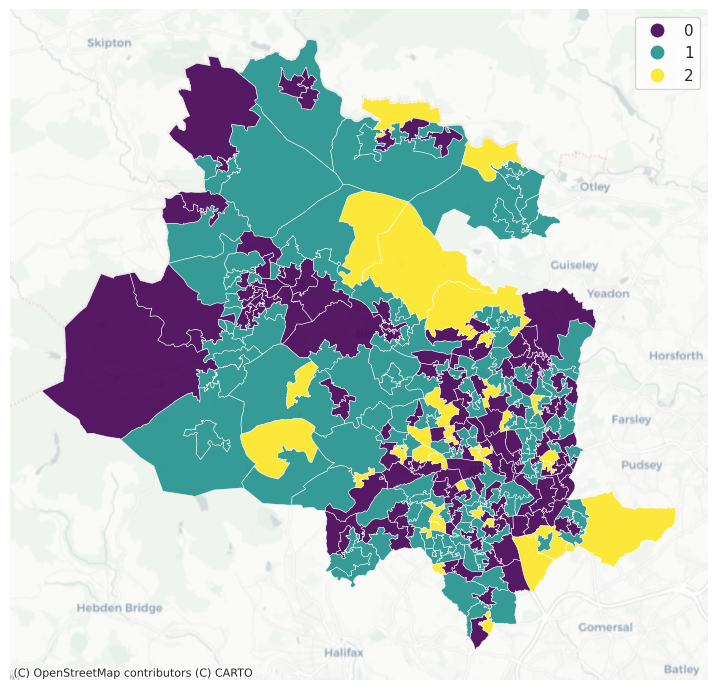

In [143]:
sns.set_theme(style='white')

# Ensure 'cluster_labels' is treated as a categorical variable
X_gdf['cluster_labels_kmedoids'] = X_gdf['cluster_labels_kmedoids'].astype('category')

fig, ax = plt.subplots(1, figsize=(9, 9))
# Build map
X_gdf.plot(
    column='cluster_labels_kmedoids',
    cmap="viridis",
    k=5,
    edgecolor="white",
    linewidth=0.4,
    alpha=0.9,
    legend=True,
    ax=ax,
)
# Add basemap
contextily.add_basemap(
    ax,
    crs=X_gdf.crs,
    source=contextily.providers.CartoDB.Positron,
)
# Remove axes
ax.set_axis_off()

In [209]:
from similarity_clustering import ClusterSimilarityMatrix, EnsembleCustering
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import MiniBatchKMeans
from sklearn.neighbors import kneighbors_graph


X = df_explore[['%non-crime', 'Night-time_ratio',
       'Temporalvolatility(CV)', '%attended', '%highacuity', 'slope',
       'lsoa_lq', 'Percentage change']]

knn_graph = kneighbors_graph(X, 10, include_self=False)

NUM_KMEANS = 32

clustering_models = NUM_KMEANS*[
    # Note: Do not set a random_state, as the variability is crucial
    MiniBatchKMeans(n_clusters=3, batch_size=6, n_init=1, max_iter=20)
]

# aggregator_clt = KMedoids(n_clusters=4,metric='euclidean',init='k-medoids++', max_iter=300, random_state=None) 
aggregator_clt = AgglomerativeClustering(linkage="ward", connectivity=None, n_clusters=3)

ens_clt=EnsembleCustering(clustering_models, aggregator_clt)
y_ensemble = ens_clt.fit_predict(X)

In [210]:
X['cluster_labels_ensemble'] = y_ensemble

In [211]:
X_geo = X.merge(df_indicators['geometry'],left_index=True,right_index=True)
X_geo['geometry'] = X_geo['geometry'].apply(loads)
X_gdf = gpd.GeoDataFrame(X_geo,geometry='geometry',crs='EPSG:4326')

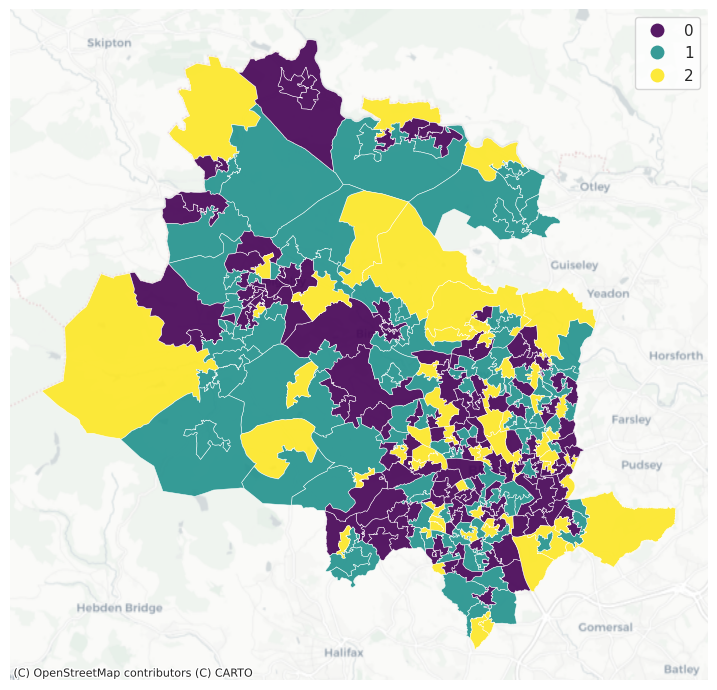

In [213]:
# Ensure 'cluster_labels' is treated as a categorical variable
X_gdf['cluster_labels_ensemble'] = X_gdf['cluster_labels_ensemble'].astype('category')

fig, ax = plt.subplots(1, figsize=(9, 9))
# Build map
X_gdf.plot(
    column='cluster_labels_ensemble',
    cmap="viridis",
    k=5,
    edgecolor="white",
    linewidth=0.4,
    alpha=0.9,
    legend=True,
    ax=ax,
)
# Add basemap
contextily.add_basemap(
    ax,
    crs=X_gdf.crs,
    source=contextily.providers.CartoDB.Positron,
)
# Remove axes
ax.set_axis_off()

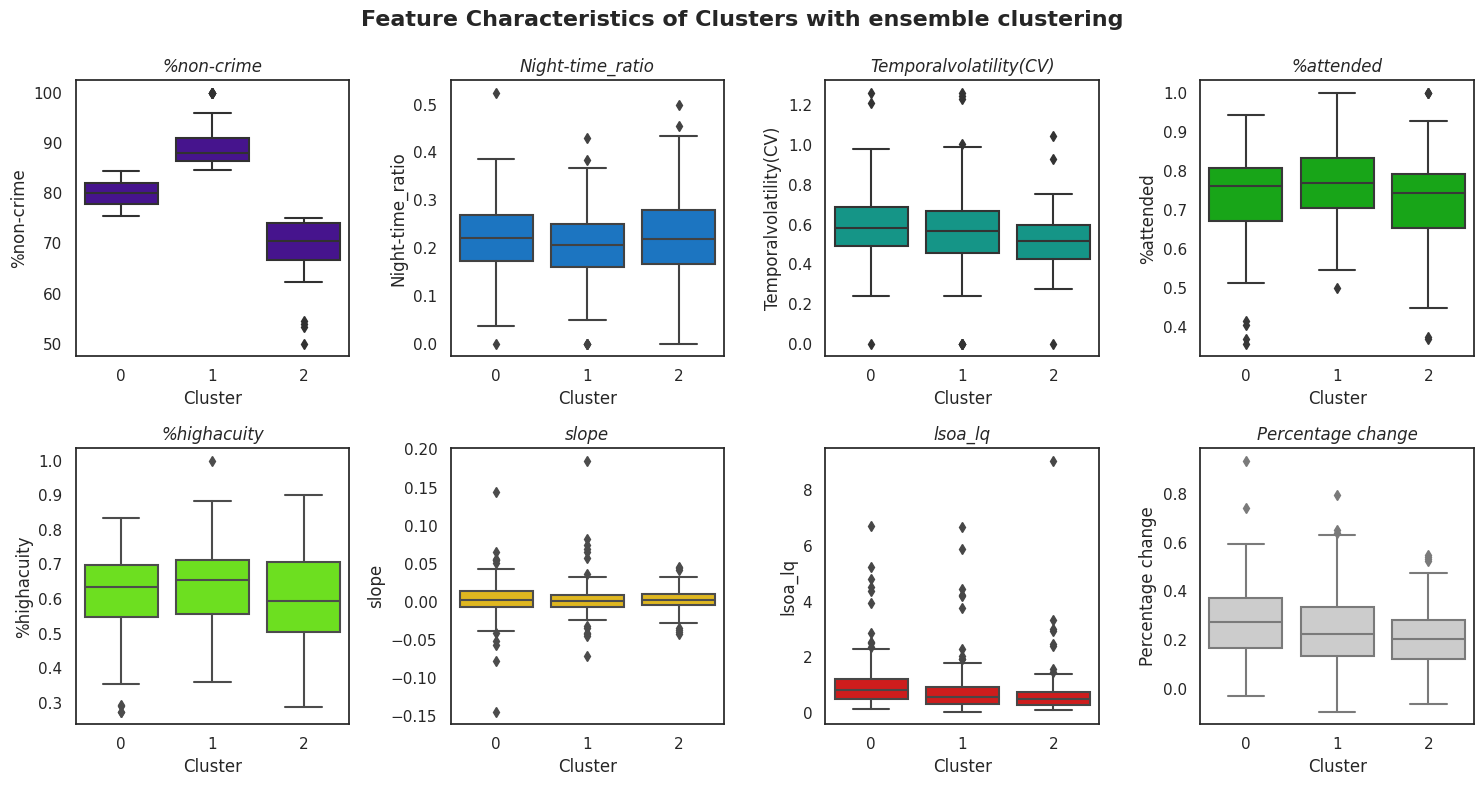

In [214]:
# Calculate the average value of each feature for each cluster
cluster_means = X.groupby('cluster_labels_ensemble').mean()
num_features = len(cluster_means.columns)

fig, axes = plt.subplots(nrows=int(np.ceil(num_features / 4)), ncols=4, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(cluster_means.columns):
    sns.boxplot(x='cluster_labels_ensemble', y=feature, data=X,ax=axes[i], color=cm.nipy_spectral((i+1)/num_features))
    # cluster_means[feature].plot(kind='bar', ax=axes[i], title=feature,color=cm.nipy_spectral(i/num_features))
    axes[i].set_ylabel(feature)
    axes[i].tick_params(axis='x', labelrotation=0)
    axes[i].set_xlabel('Cluster')
    axes[i].set_title(feature, fontstyle='italic')
    
for ax in axes.flat[cluster_means.columns.size:]:
     ax.set_axis_off()

# Set the title
fig.suptitle('Feature Characteristics of Clusters with ensemble clustering', fontsize=16,fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

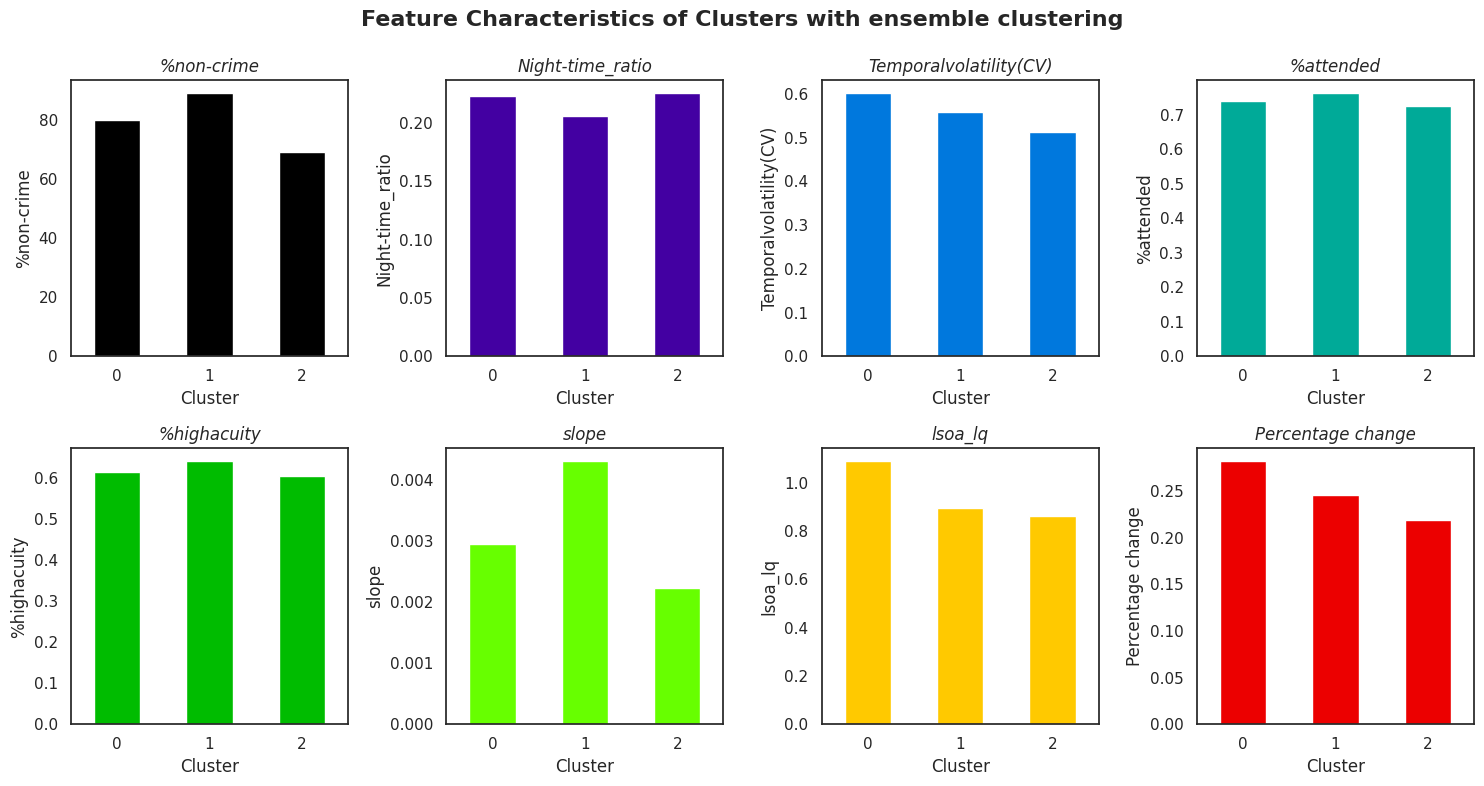

In [215]:
fig, axes = plt.subplots(nrows=int(np.ceil(num_features / 4)), ncols=4, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(cluster_means.columns):
    cluster_means[feature].plot(kind='bar', ax=axes[i], title=feature,color=cm.nipy_spectral(i/num_features))
    axes[i].set_ylabel(feature)
    axes[i].tick_params(axis='x', labelrotation=0)
    axes[i].set_xlabel('Cluster')
    axes[i].set_title(feature, fontstyle='italic')
    
for ax in axes.flat[cluster_means.columns.size:]:
     ax.set_axis_off()

# Set the title
fig.suptitle('Feature Characteristics of Clusters with ensemble clustering', fontsize=16,fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

In [208]:
X['cluster_labels_ensemble'].value_counts()

cluster_labels_ensemble
1    134
0    107
2     69
Name: count, dtype: int64

In [ ]:
sns.pairplot(X.iloc[:,np.r_[1:9,10]], hue='cluster_labels_kmedoids')

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import Normalizer

normal_values = Normalizer().fit_transform(X.iloc[:,np.r_[1:9]].values)
print(normal_values)

In [ ]:
pca = PCA()
pca.fit(normal_values)
per_var = np.round(pca.explained_variance_ratio_*100, decimals = 1)

plt.figure(figsize = (10,6))
plt.plot(range(1, len(per_var)+1), per_var.cumsum(), marker = "o", linestyle = "--")
plt.grid()
plt.ylabel("Percentage Cumulative of Explained Variance")
plt.xlabel("Number of Components")
plt.title("Explained Variance by Component")
plt.show()

In [ ]:
pca = PCA(n_components = 2)
pca.fit(normal_values)
scores_pca = pca.transform(normal_values)

distortions = []
inertias = []
map_distortion = {}
map_inertia = {}

for k in range(1, 30):
    scores_pcaModel =KMeans(n_clusters=k, init = "k-means++", random_state=42).fit(scores_pca)    
    distortions.append(sum(np.min(cdist(scores_pca, scores_pcaModel.cluster_centers_, 'euclidean'), axis=1)**2) / scores_pca.shape[0])    
    inertias.append(scores_pcaModel.inertia_)
    
    map_distortion[k] = distortions[-1]
    map_inertia[k] = inertias[-1]
    
sns.set_theme()
print("Distortion values:")
for key, val in map_distortion.items():
    print(f'{key} : {val}')

plt.plot(range(1, 30), distortions, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Distortion')
plt.title('The Elbow Method using Distortion for K-Medoids')
plt.show()

print("Inertia values:")
for key, val in map_inertia.items():
    print(f'{key} : {val}')

plt.plot(range(1, 30), inertias, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method using Inertia for K-Medoids')
plt.show()

In [ ]:
scores_pca[:,0]

In [ ]:
for n_clusters in range(2, 10):
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(scores_pca) + (n_clusters + 1) * 10])

    cluster = KMeans(n_clusters=n_clusters,init = "k-means++",random_state=42)
    cluster_labels = cluster.fit_predict(scores_pca)

    silhouette_avg = silhouette_score(scores_pca, cluster_labels)   

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(scores_pca, cluster_labels)

    y_lower = 20
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        scores_pca[:,0], scores_pca[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # Labeling the clusters
    centers = cluster.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0]/100,
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0]/100, c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering based on PCA with n_clusters = %d\n score: %.4f"
        % (n_clusters,silhouette_avg),
        fontsize=14,
        fontweight="bold",
    )

plt.show()

In [ ]:
def norm_scaling(i):
    x = (i-i.min())/(i.max()-i.min())
    return (x)

In [ ]:
X_scaled = norm_scaling(X)
distortions = []
inertias = []
map_distortion = {}
map_inertia = {}

for k in range(1, 10):
    kmeanModel = KMeans(n_clusters=k, init= 'k-means++',n_init=10, max_iter=100,random_state=42).fit(X_scaled)
    
    distortions.append(sum(np.min(cdist(X_scaled, kmeanModel.cluster_centers_, 'euclidean'), axis=1)**2) / X_scaled.shape[0])
    
    inertias.append(kmeanModel.inertia_)
    
    map_distortion[k] = distortions[-1]
    map_inertia[k] = inertias[-1]

print("Distortion values:")
for key, val in map_distortion.items():
    print(f'{key} : {val}')

plt.plot(range(1, 10), distortions, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Distortion')
plt.title('The Elbow Method using Distortion')
plt.show()

print("Inertia values:")
for key, val in map_inertia.items():
    print(f'{key} : {val}')

plt.plot(range(1, 10), inertias, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method using Inertia')
plt.show()

In [ ]:
# Adapted from https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html
for n_clusters in range(2, 10):
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X_scaled) + (n_clusters + 1) * 10])

    cluster = KMeans(n_clusters=n_clusters, init= 'k-means++',n_init=10, max_iter=100,random_state=42)
    cluster_labels = cluster.fit_predict(X_scaled)

    silhouette_avg = silhouette_score(X_scaled, cluster_labels)   

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)

    y_lower = 20
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        X.iloc[:, 0], X.iloc[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # Labeling the clusters
    centers = cluster.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d\n score: %.4f"
        % (n_clusters,silhouette_avg),
        fontsize=14,
        fontweight="bold",
    )

plt.show()

https://github.com/jaumpedro214/posts/blob/main/ensamble_clustering/simlarity_matrix.py

```python
from scipy.spatial.distance import cdist
import numpy as np

class ClusterSimilarityMatrix():
    
    def __init__(self) -> None:
        self._is_fitted = False

    def fit(self, y_clusters):
        if not self._is_fitted:
            self._is_fitted = True
            self.similarity = self.to_binary_matrix(y_clusters)
            return self

        self.similarity += self.to_binary_matrix(y_clusters)

    def to_binary_matrix(self, y_clusters):
        y_reshaped = np.expand_dims(y_clusters, axis=-1)
        return (cdist(y_reshaped, y_reshaped, 'cityblock')==0).astype(int)


class EnsembleCustering():
    def __init__(self, base_estimators, aggregator, distances=False):
        self.base_estimators = base_estimators
        self.aggregator = aggregator
        self.distances = distances

    def fit(self, X):
        X_ = X.copy()

        clt_sim_matrix = ClusterSimilarityMatrix()
        for model in self.base_estimators:
            clt_sim_matrix.fit(model.fit_predict(X=X_))
        
        sim_matrix = clt_sim_matrix.similarity
        self.cluster_matrix = sim_matrix/sim_matrix.diagonal()

        if self.distances:
            self.cluster_matrix = np.abs(np.log(self.cluster_matrix + 1e-8)) # Avoid log(0)

    def fit_predict(self, X):
        self.fit(X)
        y = self.aggregator.fit_predict(self.cluster_matrix)
        return y
```